# Hệ thống Gợi ý Việc làm(Job Recommendation System)

Hệ thống này sử dụng các kỹ thuật Học máy (Machine Learning) và Xử lý Ngôn ngữ Tự nhiên (NLP) để kết nối Ứng viên (Candidate) với các Công việc (Job Post) phù hợp nhất.

---

## 🎯 Mục tiêu
Xây dựng một mô hình **Content-based Recommendation** có khả năng:
1. **Hiểu văn bản tiếng Việt**: Phân tích hồ sơ và mô tả công việc.
2. **Khớp kỹ năng**: Đảm bảo ứng viên có các kỹ năng mà nhà tuyển dụng cần.
3. **Cân đối mức lương**: Gợi ý các công việc có mức lương phù hợp với kỳ vọng.
4. **Tối ưu hóa gợi ý**: Sắp xếp thứ tự ưu tiên dựa trên độ tương đồng tổng hợp.

## 🛠 Phương pháp tiếp cận
Chúng ta sử dụng độ đo **Cosine Similarity** trên không gian vector đa chiều:
- **Văn bản (Text)**: Chuyển đổi qua TF-IDF sau khi đã tách từ tiếng Việt.
- **Kỹ năng (Skills)**: Mã hóa nhị phân (Binary Encoding).
- **Lương (Salary)**: Chuẩn hóa về khoảng [0, 1].

---

## 📋 Cấu trúc Notebook
1. **Phần 1**: Giới thiệu & Mục tiêu.
2. **Phần 2**: Load dữ liệu & Khám phá dữ liệu (EDA).
3. **Phần 3**: Tiền xử lý dữ liệu & NLP tiếng Việt.
4. **Phần 4**: Xây dựng Vector đại diện (Vectorization).
5. **Phần 5**: Mô hình gợi ý & Demo kết quả.
6. **Phần 6**: Đánh giá & Hướng phát triển.


# Phần 2: LOAD DỮ LIỆU & EDA


## 2.1. Import thư viện cần thiết

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
import warnings
import re
from underthesea import word_tokenize
from wordcloud import WordCloud
from sentence_transformers import SentenceTransformer
import torch
from rapidfuzz import process, fuzz
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'


## 2.1.1. Khởi tạo mô hình Embedding (Sentence-BERT)

Sử dụng mô hình `paraphrase-multilingual-MiniLM-L12-v2` hỗ trợ đa ngôn ngữ (bao gồm tiếng Việt) để chuyển đổi văn bản thành các vector mang ý nghĩa ngữ nghĩa.


In [268]:
# Khởi tạo mô hình SentenceTransformer
embedding_model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

# Kiểm tra thiết bị đang sử dụng (CPU/GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
embedding_model.to(device)
print(f"Mô hình Embedding đã được tải trên: {device}")


Mô hình Embedding đã được tải trên: cpu


## 2.2. Load dữ liệu từ CSV

In [269]:
# Load các bảng dữ liệu chính
candidates = pd.read_csv("../data/csv_data/candidates.csv")
users = pd.read_csv("../data/csv_data/users.csv")
candidates_skills = pd.read_csv("../data/csv_data/candidates_skills.csv")
skills = pd.read_csv("../data/csv_data/skills.csv")

job_posts = pd.read_csv("../data/csv_data/job_posts.csv")
job_posts_skills = pd.read_csv("../data/csv_data/job_posts_skills.csv")
industries = pd.read_csv("../data/csv_data/industries.csv")
levels = pd.read_csv("../data/csv_data/levels.csv")
job_types = pd.read_csv("../data/csv_data/job_types.csv")

print("=== THÔNG TIN CÁC BẢNG DỮ LIỆU ===")
print(f"Candidates: {len(candidates)} records")
print(f"Users: {len(users)} records")
print(f"Candidates Skills: {len(candidates_skills)} records")
print(f"Skills: {len(skills)} records")
print(f"Job Posts: {len(job_posts)} records")
print(f"Job Posts Skills: {len(job_posts_skills)} records")
print(f"Industries: {len(industries)} records")
print(f"Levels: {len(levels)} records")
print(f"Job Types: {len(job_types)} records")


=== THÔNG TIN CÁC BẢNG DỮ LIỆU ===
Candidates: 100 records
Users: 201 records
Candidates Skills: 2222 records
Skills: 62 records
Job Posts: 327 records
Job Posts Skills: 829 records
Industries: 89 records
Levels: 43 records
Job Types: 8 records


## 2.3. Khám phá dữ liệu Candidate

In [270]:
print("=== CANDIDATES TABLE ===")
print(candidates.info())
print("\n--- Sample data ---")
candidates.head()


=== CANDIDATES TABLE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   dob            49 non-null     object 
 1   education      59 non-null     object 
 2   expect_salary  55 non-null     float64
 3   gender         54 non-null     float64
 4   id             100 non-null    object 
dtypes: float64(2), object(3)
memory usage: 4.0+ KB
None

--- Sample data ---


,dob,education,expect_salary,gender,id
0,1998-02-10,,39000000.0,1.0,00fc28fb-86af-440c-ae99-6b98ad7debdb
1,1992-07-30,Thạc sĩ CNTT,35000000.0,1.0,04149279-92bf-422b-a0df-798f3611a1c5
2,1995-12-01,Cử nhân Quản trị kinh doanh,15000000.0,0.0,0746450e-92c6-4c1a-8fc7-ea2ee9cc6d42
3,1999-10-05,Đại học Khoa học Tự nhiên,18000000.0,1.0,0944b2dc-7e8f-4e92-9263-596d6b978946
4,1994-07-26,Cử nhân Công nghệ thông tin,0.0,1.0,0dffbd1a-2d8a-431f-ae68-fd314fbe46dc


In [271]:
print("=== USERS TABLE (chứa summary) ===")
print(users.info())
print("\n--- Sample data ---")
users[['id', 'full_name', 'summary']].head()


=== USERS TABLE (chứa summary) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           201 non-null    object 
 1   created_at   201 non-null    object 
 2   email        200 non-null    object 
 3   full_name    194 non-null    object 
 4   image_url    201 non-null    object 
 5   password     201 non-null    object 
 6   phone        107 non-null    object 
 7   summary      126 non-null    object 
 8   updated_at   201 non-null    object 
 9   user_status  201 non-null    object 
 10  username     201 non-null    object 
 11  region_id    0 non-null      float64
dtypes: float64(1), object(11)
memory usage: 19.0+ KB
None

--- Sample data ---


,id,full_name,summary
0,00fc28fb-86af-440c-ae99-6b98ad7debdb,Lê Quốc Việt,Frontend Developer với ReactJS
1,04149279-92bf-422b-a0df-798f3611a1c5,Lê Minh Hoàng,Frontend Developer
2,04991cc9-2d5f-4a33-846b-cb328c9adfde,Đặng Minh Lan,Frontend developer ReactJS.
3,05a1273e-0dfb-4f97-ba5f-400ffb39244f,Global Soft,Công ty phần mềm quốc tế
4,06c39b46-dc0c-40ed-af9c-1fd90e0e1841,Võ Phúc,Tester manual và automation.


In [272]:
# Merge candidates với users để lấy summary
candidates_full = candidates.merge(users[['id', 'full_name', 'summary']], on='id', how='left')
print("=== CANDIDATES FULL ===")
print(f"Shape: {candidates_full.shape}")
candidates_full.head()


=== CANDIDATES FULL ===
Shape: (100, 7)


,dob,education,expect_salary,gender,id,full_name,summary
0,1998-02-10,,39000000.0,1.0,00fc28fb-86af-440c-ae99-6b98ad7debdb,Lê Quốc Việt,Frontend Developer với ReactJS
1,1992-07-30,Thạc sĩ CNTT,35000000.0,1.0,04149279-92bf-422b-a0df-798f3611a1c5,Lê Minh Hoàng,Frontend Developer
2,1995-12-01,Cử nhân Quản trị kinh doanh,15000000.0,0.0,0746450e-92c6-4c1a-8fc7-ea2ee9cc6d42,Nguyễn Hùng,Nhân sự tuyển dụng IT.
3,1999-10-05,Đại học Khoa học Tự nhiên,18000000.0,1.0,0944b2dc-7e8f-4e92-9263-596d6b978946,Lê Thanh An,"Kỹ sư phần mềm, làm việc với hệ thống lớn."
4,1994-07-26,Cử nhân Công nghệ thông tin,0.0,1.0,0dffbd1a-2d8a-431f-ae68-fd314fbe46dc,NaN,Nhân sự tuyển dụng IT.


In [273]:
# Thống kê missing values cho candidates
print("=== MISSING VALUES - CANDIDATES ===")
missing_candidates = candidates_full.isnull().sum()
missing_percent = (missing_candidates / len(candidates_full) * 100).round(2)
pd.DataFrame({'Missing Count': missing_candidates, 'Missing %': missing_percent})


=== MISSING VALUES - CANDIDATES ===


,Missing Count,Missing %
dob,51,51.0
education,41,41.0
expect_salary,45,45.0
gender,46,46.0
id,0,0.0
full_name,3,3.0
summary,41,41.0


## 2.4. Khám phá dữ liệu Job Posts

In [274]:
print("=== JOB POSTS TABLE ===")
print(job_posts.info())
print("\n--- Sample data ---")
job_posts.head()


=== JOB POSTS TABLE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327 entries, 0 to 326
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            327 non-null    object 
 1   created_at    327 non-null    object 
 2   description   311 non-null    object 
 3   ended_time    185 non-null    object 
 4   quantity      327 non-null    int64  
 5   salary        298 non-null    float64
 6   salary_type   267 non-null    object 
 7   status        250 non-null    object 
 8   title         288 non-null    object 
 9   updated_at    327 non-null    object 
 10  industry_id   327 non-null    int64  
 11  job_type_id   327 non-null    int64  
 12  level_id      327 non-null    int64  
 13  recruiter_id  327 non-null    object 
 14  region_id     327 non-null    int64  
dtypes: float64(1), int64(5), object(9)
memory usage: 38.4+ KB
None

--- Sample data ---


,id,created_at,description,ended_time,quantity,salary,salary_type,status,title,updated_at,industry_id,job_type_id,level_id,recruiter_id,region_id
0,002d35b1-1ff1-45f8-b0ef-7897d2584554,2025-06-25 22:14:31.124041,Hiểu biết về Machine Learning,2024-08-24 00:00:00.000000,-1,25000000.0,PROJECT,PRIVATE,Lập trình viên Python,2025-11-22 22:14:31.124060,62,5,38,78f2025f-0195-47ef-9d50-f8ffc934395b,12
1,007cd194-f5de-4af1-b299-ffe7dc314e76,2025-11-15 21:28:52.735120,Yêu cầu kinh nghiệm 2 năm,2024-03-21 00:00:00.000000,2,10000000.0,MONTHS,NaN,Lập trình viên Python,2025-11-27 21:28:52.735124,89,7,28,4f1dd8f2-518e-4e07-9c4d-0848791327a4,11
2,0138730f-d1f2-49c4-a72b-582f8a75ba48,2025-08-17 22:14:31.139596,Có thể làm việc nhóm tốt,NaN,3,18000000.0,NaN,PUBLIC,Kỹ sư dữ liệu,2025-11-27 22:14:31.139604,84,6,25,56a915b2-6add-4e42-b31d-81fda3bf7485,82
3,0181d9a3-aa61-490e-b8f7-aa219e80e74a,2025-08-16 22:14:31.190260,undefined,NaN,1,18000000.0,NEGOTIATION,NaN,Kỹ sư AI,2025-11-25 22:14:31.190271,28,7,15,ea651dc9-312a-49a3-8c6c-3b9be7615a1a,91
4,03d649a5-a55b-4162-9064-4e54c6d43a11,2025-12-08 21:28:52.734655,Hiểu biết về Machine Learning,2025-03-22 00:00:00.000000,3,20000000.0,NaN,PRIVATE,Kỹ sư dữ liệu,2025-12-06 21:28:52.734660,4,2,8,41420dc1-d801-4065-bec6-7dc885cb2b76,80


In [275]:
# Merge job_posts với industries, levels, job_types
job_posts_full = job_posts.merge(industries[['id', 'name']], left_on='industry_id', right_on='id', how='left', suffixes=('', '_industry'))
job_posts_full = job_posts_full.rename(columns={'name': 'industry_name'})
job_posts_full = job_posts_full.drop(columns=['id_industry'], errors='ignore')

job_posts_full = job_posts_full.merge(levels[['id', 'name']], left_on='level_id', right_on='id', how='left', suffixes=('', '_level'))
job_posts_full = job_posts_full.rename(columns={'name': 'level_name'})
job_posts_full = job_posts_full.drop(columns=['id_level'], errors='ignore')

job_posts_full = job_posts_full.merge(job_types[['id', 'name']], left_on='job_type_id', right_on='id', how='left', suffixes=('', '_job_type'))
job_posts_full = job_posts_full.rename(columns={'name': 'job_type_name'})
job_posts_full = job_posts_full.drop(columns=['id_job_type'], errors='ignore')

print("=== JOB POSTS FULL ===")
print(f"Shape: {job_posts_full.shape}")
job_posts_full[['id', 'title', 'description', 'salary', 'salary_type', 'industry_name', 'level_name', 'job_type_name']].head()


=== JOB POSTS FULL ===
Shape: (327, 18)


,id,title,description,salary,salary_type,industry_name,level_name,job_type_name
0,002d35b1-1ff1-45f8-b0ef-7897d2584554,Lập trình viên Python,Hiểu biết về Machine Learning,25000000.0,PROJECT,Sư phạm Lịch sử,Nhà văn / Biên tập viên (Writer),Hợp đồng ngắn hạn
1,007cd194-f5de-4af1-b299-ffe7dc314e76,Lập trình viên Python,Yêu cầu kinh nghiệm 2 năm,10000000.0,MONTHS,Kỹ thuật Robot,Hiệu trưởng / Giám đốc trung tâm (Principal),Thời vụ
2,0138730f-d1f2-49c4-a72b-582f8a75ba48,Kỹ sư dữ liệu,Có thể làm việc nhóm tốt,18000000.0,NaN,Kỹ thuật điều khiển và tự động hóa,Giám đốc tài chính (CFO),Cộng tác viên
3,0181d9a3-aa61-490e-b8f7-aa219e80e74a,Kỹ sư AI,undefined,18000000.0,NEGOTIATION,Xây dựng cảng - công trình biển,Giám sát viên (Supervisor),Thời vụ
4,03d649a5-a55b-4162-9064-4e54c6d43a11,Kỹ sư dữ liệu,Hiểu biết về Machine Learning,20000000.0,NaN,An ninh mạng,Chuyên gia (Expert),Bán thời gian


In [276]:
# Thống kê missing values cho job_posts
print("=== MISSING VALUES - JOB POSTS ===")
missing_jobs = job_posts_full.isnull().sum()
missing_percent_jobs = (missing_jobs / len(job_posts_full) * 100).round(2)
pd.DataFrame({'Missing Count': missing_jobs, 'Missing %': missing_percent_jobs})


=== MISSING VALUES - JOB POSTS ===


,Missing Count,Missing %
id,0,0.00
created_at,0,0.00
description,16,4.89
ended_time,142,43.43
quantity,0,0.00
salary,29,8.87
salary_type,60,18.35
status,77,23.55
title,39,11.93
updated_at,0,0.00


## 2.5. Khám phá dữ liệu Skills

In [277]:
print("=== SKILLS TABLE ===")
skills.head(10)

=== SKILLS TABLE ===


,id,description,name
0,1,Xây dựng mô hình học máy.,Machine Learning
1,2,Thư viện frontend cho UI.,ReactJS
2,3,Framework backend từ Microsoft.,ASP.NET
3,4,Xử lý ảnh và thị giác máy tính.,Computer Vision
4,5,Quản lý lớp học hiệu quả.,Class Management
5,6,"Dùng trong backend, AI và automation.",Python
6,7,Quản lý container tối ưu.,Kubernetes
7,8,Sáng tạo trong giải pháp và ý tưởng.,Creativity
8,9,Phiên bản mở rộng của JavaScript.,TypeScript
9,10,Bảo mật ứng dụng và hệ thống.,Cyber Security


In [278]:
# Tạo mapping skills cho candidates
candidate_skills_grouped = candidates_skills.merge(skills[['id', 'name']], left_on='skills_id', right_on='id', how='left')
candidate_skills_agg = candidate_skills_grouped.groupby('candidate_id')['name'].apply(lambda x: ', '.join(x.dropna())).reset_index()
candidate_skills_agg.columns = ['candidate_id', 'skills_list']
print("=== CANDIDATE SKILLS AGGREGATED ===")
candidate_skills_agg.head()


=== CANDIDATE SKILLS AGGREGATED ===


,candidate_id,skills_list
0,00fc28fb-86af-440c-ae99-6b98ad7debdb,"Python, Cyber Security, MongoDB, Laravel, Flask, Angular, Teamwork, Django, iOS, Spring Boot, SE..."
1,04149279-92bf-422b-a0df-798f3611a1c5,"ASP.NET, Computer Vision, Python, Creativity, TypeScript, Flask, Digital Marketing, Teamwork, Me..."
2,0746450e-92c6-4c1a-8fc7-ea2ee9cc6d42,"ReactJS, Class Management, Creativity, Cyber Security, MySQL, Revit, Laravel, Flask, Angular, An..."
3,0944b2dc-7e8f-4e92-9263-596d6b978946,"Machine Learning, ReactJS, Class Management, Python, Creativity, Cyber Security, JavaScript, Mon..."
4,0dffbd1a-2d8a-431f-ae68-fd314fbe46dc,"Python, Creativity, Revit, MongoDB, Laravel, Digital Marketing, Android, Audit, SQL, Time Manage..."


In [279]:
# Tạo mapping skills cho job_posts
job_skills_grouped = job_posts_skills.merge(skills[['id', 'name']], left_on='skills_id', right_on='id', how='left')
job_skills_agg = job_skills_grouped.groupby('job_post_id')['name'].apply(lambda x: ', '.join(x.dropna())).reset_index()
job_skills_agg.columns = ['job_post_id', 'skills_list']
print("=== JOB POSTS SKILLS AGGREGATED ===")
job_skills_agg.head()


=== JOB POSTS SKILLS AGGREGATED ===


,job_post_id,skills_list
0,002d35b1-1ff1-45f8-b0ef-7897d2584554,"Teamwork, NodeJS, Business Analysis, Deep Learning"
1,0138730f-d1f2-49c4-a72b-582f8a75ba48,"Machine Learning, Docker, Spring Boot, Azure Cloud, VueJS"
2,0181d9a3-aa61-490e-b8f7-aa219e80e74a,"VueJS, Accounting"
3,04621b89-3368-4224-b0f6-01b37e71ec51,"Revit, AutoCAD, Audit, Time Management, Networking"
4,053b4ace-3b98-48de-9baf-4339e5980fd4,"Revit, Customer Service"


## 2.6. Trực quan hóa dữ liệu (EDA)

Tại bước này, chúng ta khám phá các đặc điểm của dữ liệu để có cái nhìn tổng quan về dữ liệu bài đăng tuyển d và ứng viên.


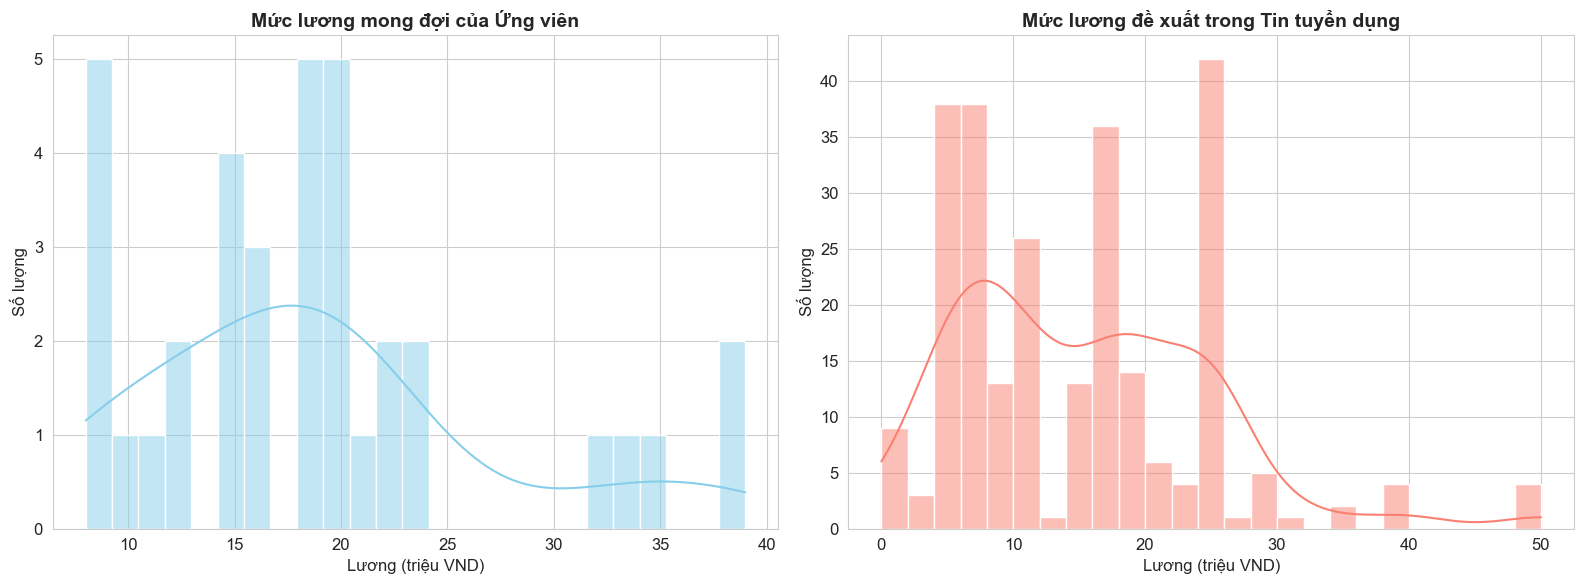

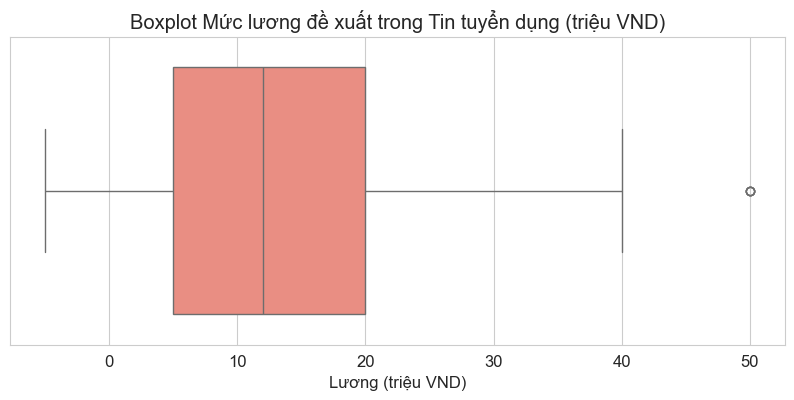

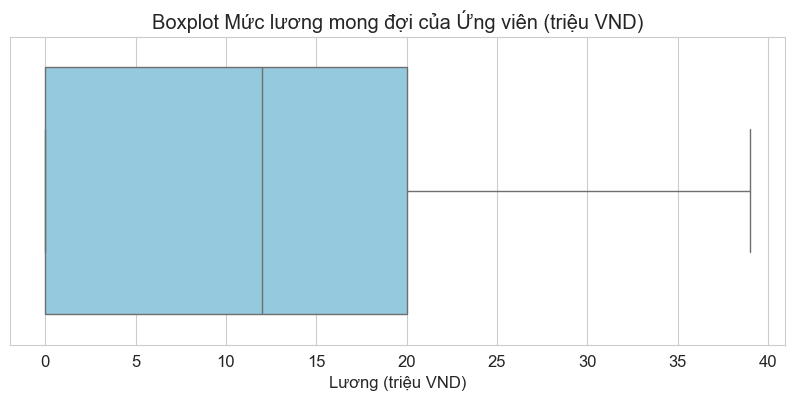

Số lượng job_posts bị trùng id: 0
Số lượng candidates bị trùng id: 0


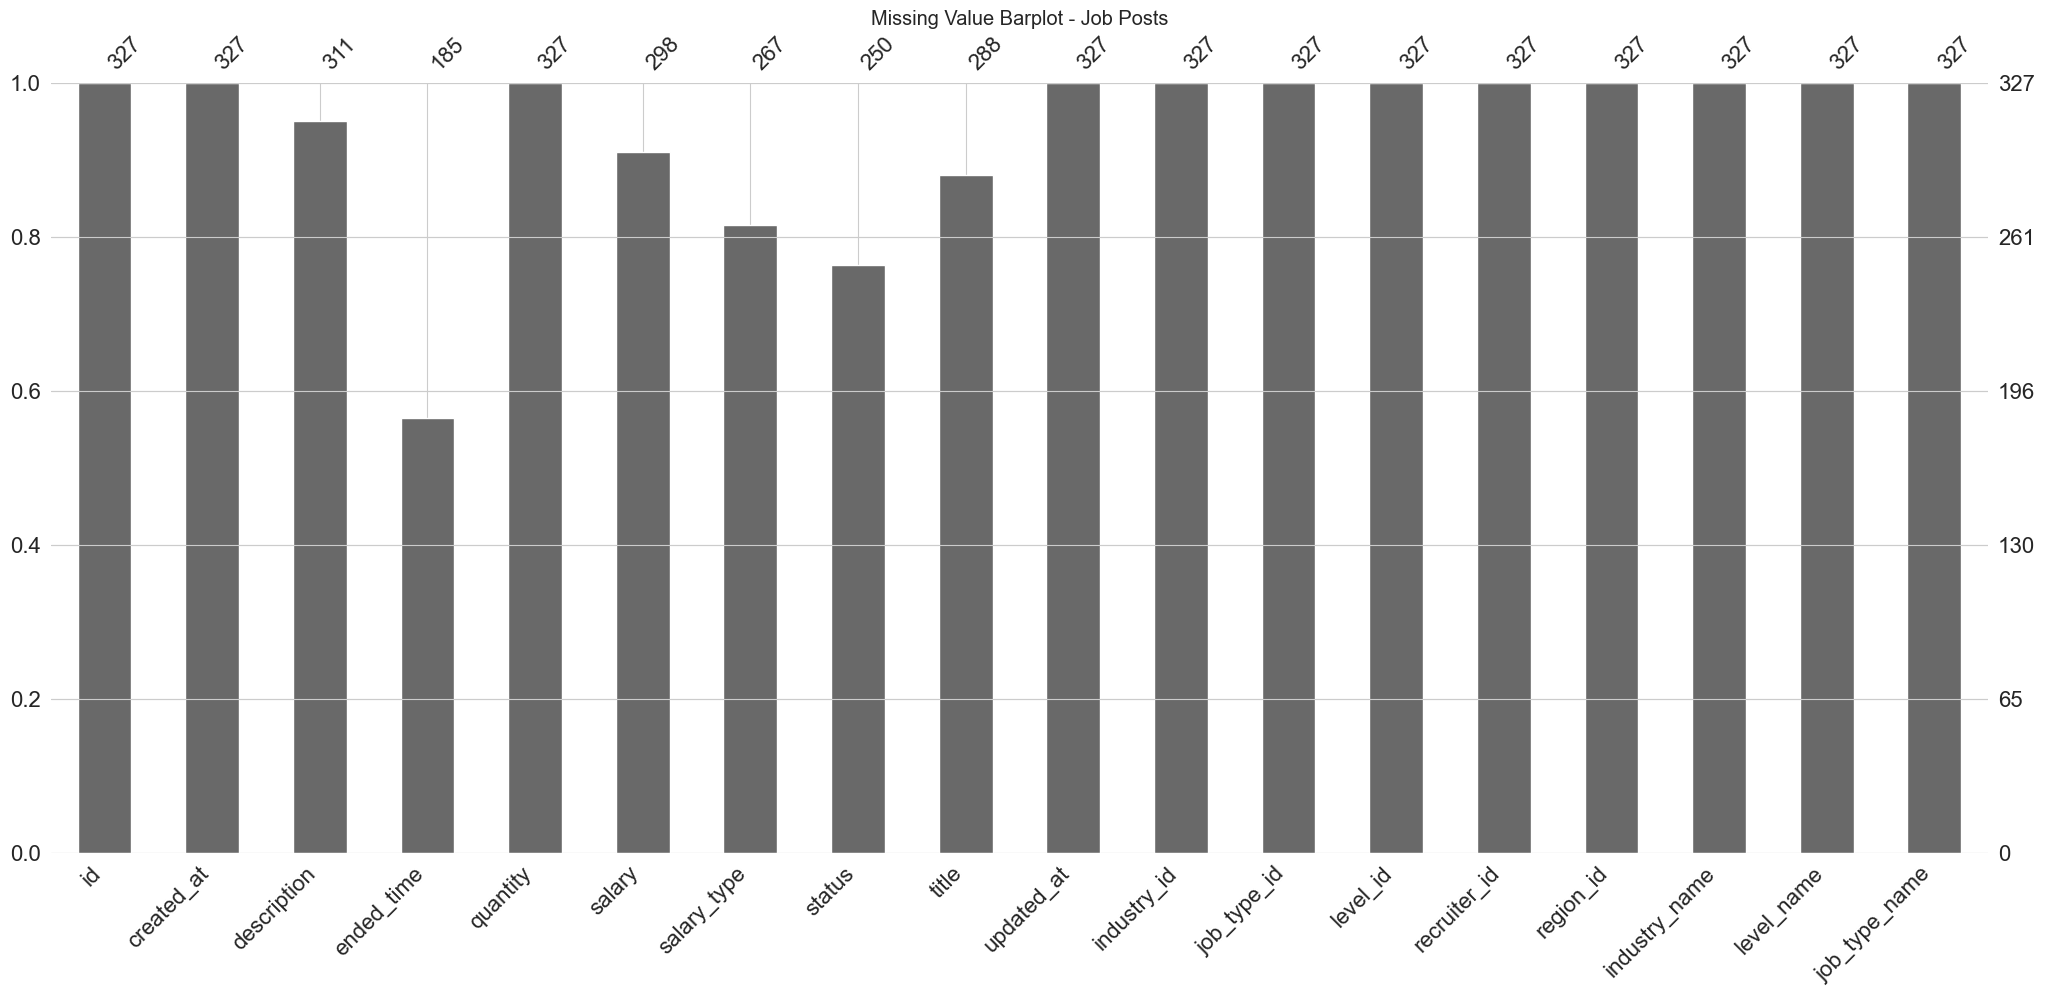

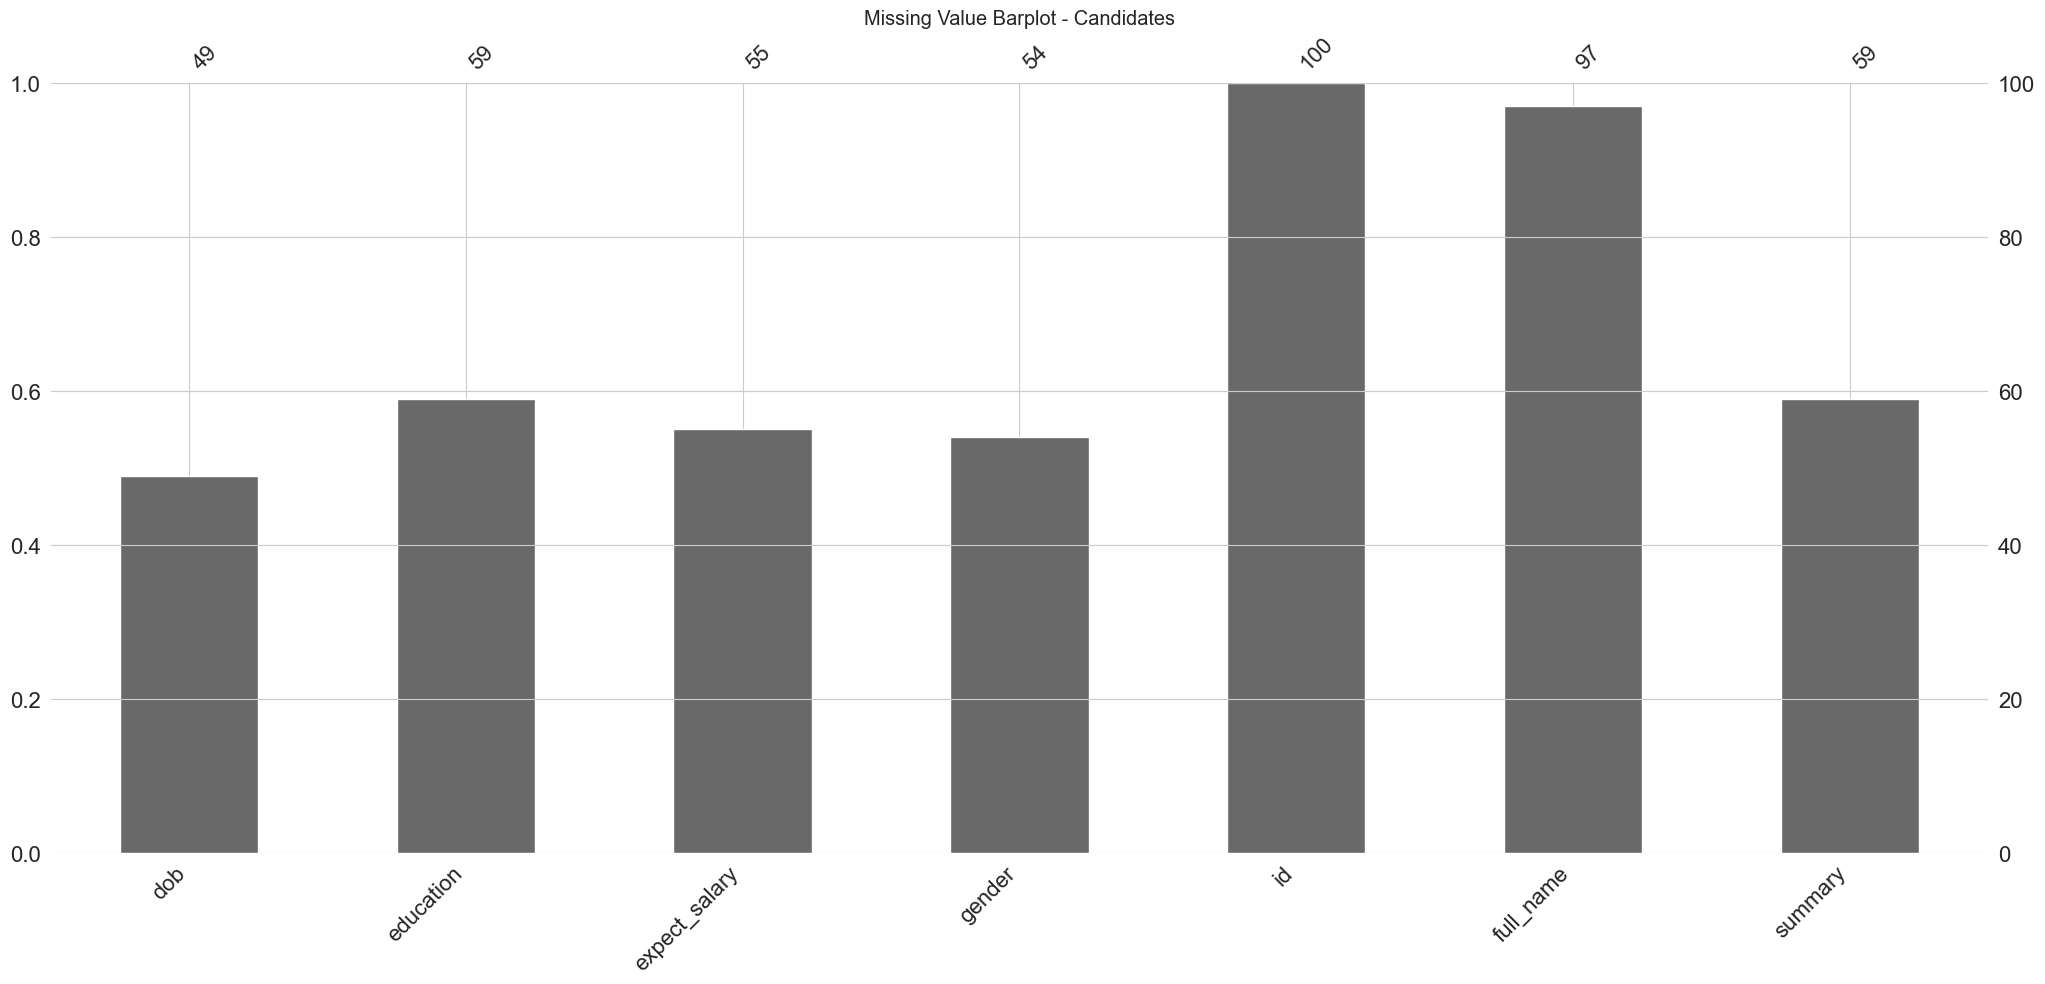

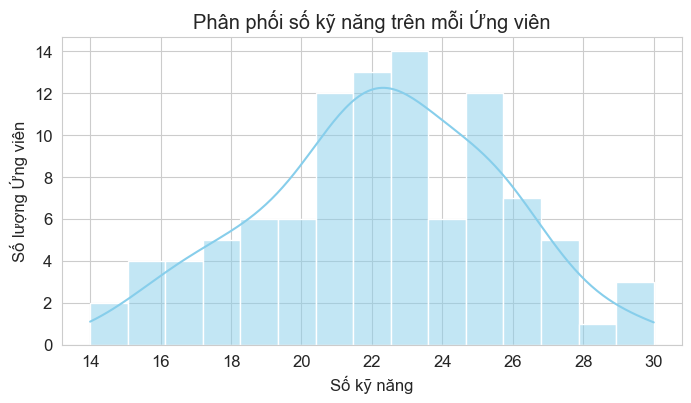

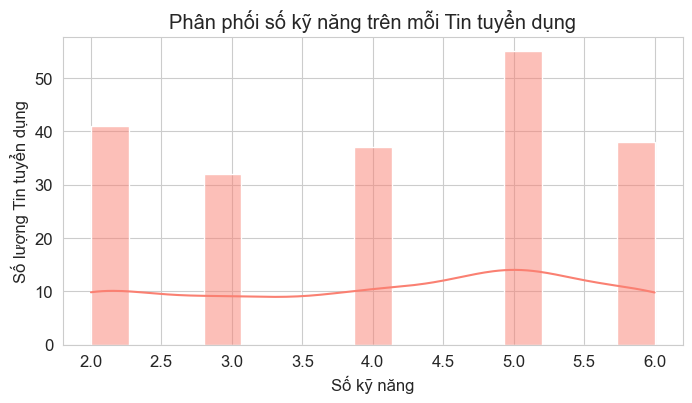

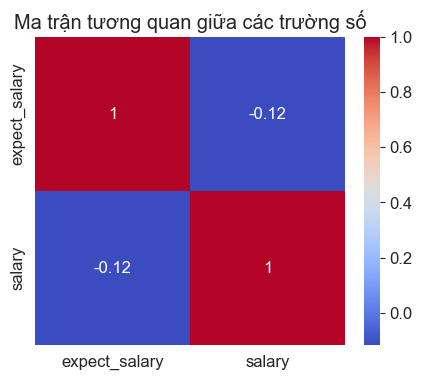

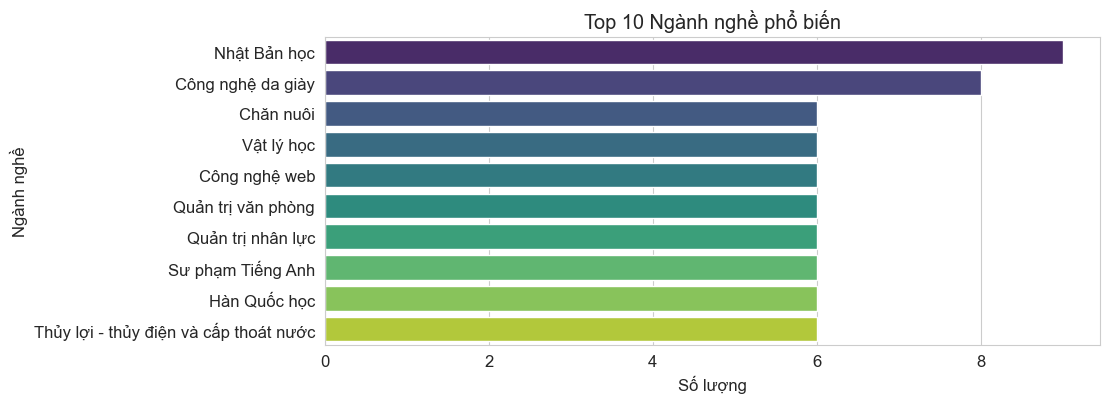

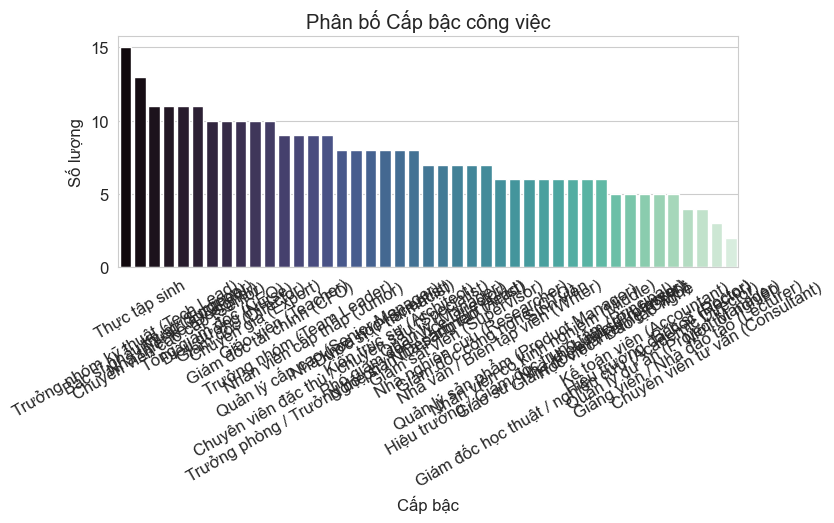

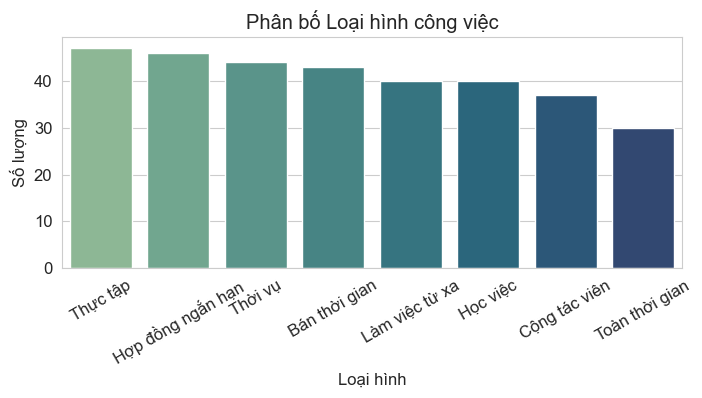

In [280]:
# palette = sns.color_palette("pastel")
sns.color_palette("blend:#7AB,#EDA", as_cmap=True)

# 1. Phân bố salary của candidates và job posts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Candidate expect salary
valid_salary_candidates = candidates_full[candidates_full['expect_salary'] > 0]['expect_salary']
sns.histplot(valid_salary_candidates / 1000000, bins=25, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Mức lương mong đợi của Ứng viên', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lương (triệu VND)')
axes[0].set_ylabel('Số lượng')

# Job posts salary
valid_salary_jobs = job_posts_full[job_posts_full['salary'] > 0]['salary']
sns.histplot(valid_salary_jobs / 1000000, bins=25, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Mức lương đề xuất trong Tin tuyển dụng', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lương (triệu VND)')
axes[1].set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

# =========================
# BỔ SUNG EDA CHUYÊN SÂU
# =========================

# 1. Phân tích Outlier cho lương (Boxplot)
plt.figure(figsize=(10, 4))
sns.boxplot(x=job_posts_full['salary'] / 1e6, color='salmon')
plt.title('Boxplot Mức lương đề xuất trong Tin tuyển dụng (triệu VND)')
plt.xlabel('Lương (triệu VND)')
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=candidates_full['expect_salary'] / 1e6, color='skyblue')
plt.title('Boxplot Mức lương mong đợi của Ứng viên (triệu VND)')
plt.xlabel('Lương (triệu VND)')
plt.show()

# 2. Kiểm tra trùng lặp
print('Số lượng job_posts bị trùng id:', job_posts['id'].duplicated().sum())
print('Số lượng candidates bị trùng id:', candidates['id'].duplicated().sum())

# 3. Phân tích missing value trực quan
try:
    import missingno as msno
except ImportError:
    msno = None

if msno is not None:
    plt.figure(figsize=(12, 3))
    msno.bar(job_posts_full)
    plt.title('Missing Value Barplot - Job Posts')
    plt.show()
    plt.figure(figsize=(12, 3))
    msno.bar(candidates_full)
    plt.title('Missing Value Barplot - Candidates')
    plt.show()
else:
    print('missingno chưa được cài đặt, bỏ qua trực quan missing value.')

# 4. Phân phối số kỹ năng trên mỗi ứng viên/công việc
plt.figure(figsize=(8, 4))
candidate_skill_counts = candidates_skills.groupby('candidate_id').size()
sns.histplot(candidate_skill_counts, bins=15, color='skyblue', kde=True)
plt.title('Phân phối số kỹ năng trên mỗi Ứng viên')
plt.xlabel('Số kỹ năng')
plt.ylabel('Số lượng Ứng viên')
plt.show()

plt.figure(figsize=(8, 4))
job_skill_counts = job_posts_skills.groupby('job_post_id').size()
sns.histplot(job_skill_counts, bins=15, color='salmon', kde=True)
plt.title('Phân phối số kỹ năng trên mỗi Tin tuyển dụng')
plt.xlabel('Số kỹ năng')
plt.ylabel('Số lượng Tin tuyển dụng')
plt.show()

# 5. Phân tích tương quan các trường số (nếu có)
if 'expect_salary' in candidates_full.columns and 'salary' in job_posts_full.columns:
    salary_series = job_posts_full['salary'].reindex_like(candidates_full)
    if isinstance(salary_series, pd.DataFrame):
        salary_series = salary_series.squeeze()
    corr_df = pd.DataFrame({
        'expect_salary': candidates_full['expect_salary'],
        'salary': salary_series if 'salary' in job_posts_full.columns else pd.Series([None]*len(candidates_full))
    })
    plt.figure(figsize=(5, 4))
    sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')
    plt.title('Ma trận tương quan giữa các trường số')
    plt.show()

# 6. Phân tích đa dạng ngành nghề, cấp bậc, loại hình
plt.figure(figsize=(10, 4))
sns.countplot(y=job_posts_full['industry_name'], order=job_posts_full['industry_name'].value_counts().index[:10], palette='viridis')
plt.title('Top 10 Ngành nghề phổ biến')
plt.xlabel('Số lượng')
plt.ylabel('Ngành nghề')
plt.show()

plt.figure(figsize=(8, 3))
sns.countplot(x=job_posts_full['level_name'], order=job_posts_full['level_name'].value_counts().index, palette='mako')
plt.title('Phân bố Cấp bậc công việc')
plt.xlabel('Cấp bậc')
plt.ylabel('Số lượng')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8, 3))
sns.countplot(x=job_posts_full['job_type_name'], order=job_posts_full['job_type_name'].value_counts().index, palette='crest')
plt.title('Phân bố Loại hình công việc')
plt.xlabel('Loại hình')
plt.ylabel('Số lượng')
plt.xticks(rotation=30)
plt.show()


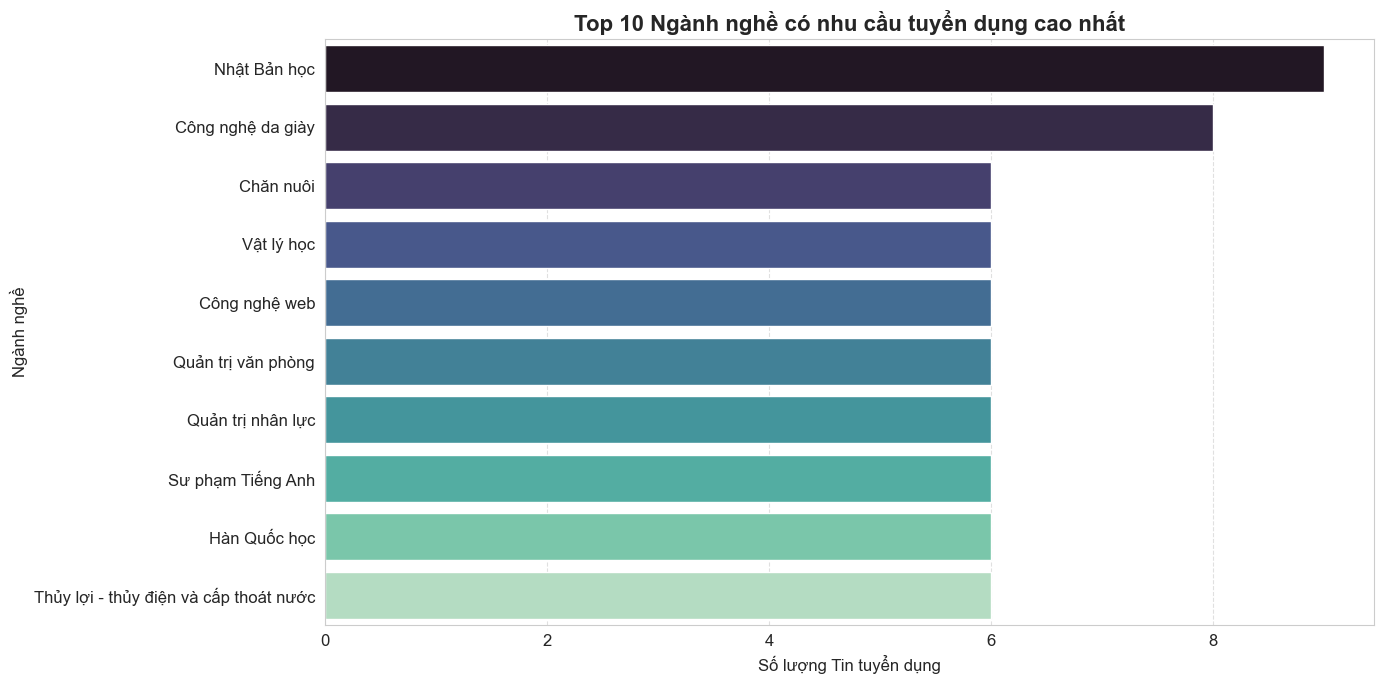

In [281]:
# 2. Top 10 Industries phổ biến nhất
plt.figure(figsize=(14, 7))
top_industries = job_posts_full['industry_name'].value_counts().head(10)
sns.barplot(x=top_industries.values, y=top_industries.index, palette="mako")
plt.title('Top 10 Ngành nghề có nhu cầu tuyển dụng cao nhất', fontsize=16, fontweight='bold')
plt.xlabel('Số lượng Tin tuyển dụng', fontsize=12)
plt.ylabel('Ngành nghề', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


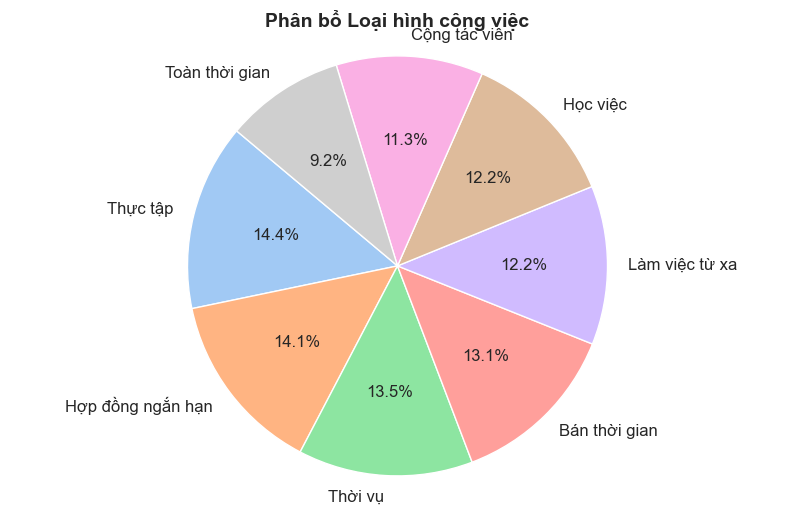

In [282]:
# 3. Phân bố Loại hình công việc (Job Types)
plt.figure(figsize=(10, 6))
job_type_dist = job_posts_full['job_type_name'].value_counts()
colors = sns.color_palette("pastel")[0:len(job_type_dist)]
plt.pie(job_type_dist, labels=job_type_dist.index, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'white'})
plt.title('Phân bổ Loại hình công việc', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()


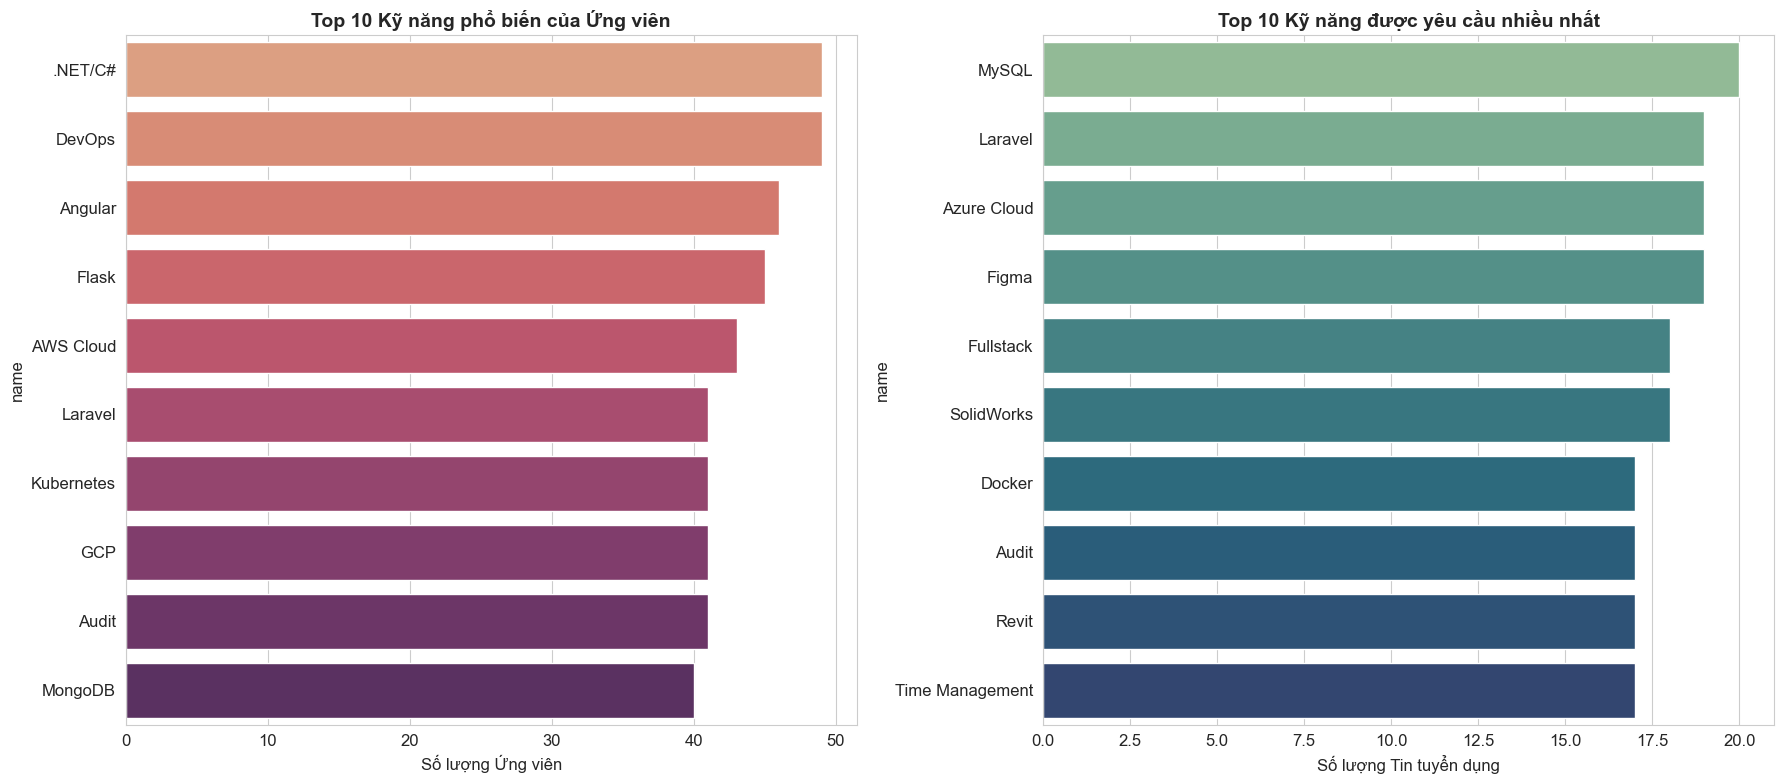

In [283]:
# 4. Top 10 Skills phổ biến
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Candidates' Skills
all_candidate_skills = candidates_skills.merge(skills[['id', 'name']], left_on='skills_id', right_on='id')
top_candidate_skills = all_candidate_skills['name'].value_counts().head(10)
sns.barplot(x=top_candidate_skills.values, y=top_candidate_skills.index, ax=axes[0], palette="flare")
axes[0].set_title('Top 10 Kỹ năng phổ biến của Ứng viên', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số lượng Ứng viên')

# Job Posts' Skills
all_job_skills = job_posts_skills.merge(skills[['id', 'name']], left_on='skills_id', right_on='id')
top_job_skills = all_job_skills['name'].value_counts().head(10)
sns.barplot(x=top_job_skills.values, y=top_job_skills.index, ax=axes[1], palette="crest")
axes[1].set_title('Top 10 Kỹ năng được yêu cầu nhiều nhất', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Số lượng Tin tuyển dụng')

plt.tight_layout()
plt.show()


# Phần 3: TIỀN XỬ LÝ DỮ LIỆU & VIETNAMESE NLP

## 3.0. Chuẩn hóa Kỹ năng (Skill Canonicalization)

Sử dụng Embedding Similarity để ánh xạ các biến thể của kỹ năng (ví dụ: "ML", "Machine Learning") về một dạng chuẩn duy nhất. Điều này giúp tăng độ chính xác khi khớp kỹ năng.


In [284]:
def get_skill_canonical_map(skills_df, threshold=0.85):
    """
    Chuẩn hóa kỹ năng: fuzzy matching với danh sách kỹ năng chuẩn
    """
    canonical_skills = skills_df['name'].tolist()
    skill_embeddings = embedding_model.encode(canonical_skills)

    def find_canonical(skill_name):
        skill_lower = skill_name.lower().strip()
        # Fuzzy matching với danh sách kỹ năng chuẩn
        match, score, _ = process.extractOne(
            skill_lower,
            canonical_skills,
            scorer=fuzz.token_sort_ratio
        )
        if score >= threshold * 100:  # rapidfuzz trả về 0-100
            return match
        return skill_name  # Giữ nguyên nếu không đủ độ tự tin

    return find_canonical

# Khởi tạo function canonicalize
canonicalize_skill = get_skill_canonical_map(skills)

# Test
print(f"Canonical 'ML': {canonicalize_skill('ML')}")
print(f"Canonical 'React': {canonicalize_skill('React')}")
print(f"Canonical 'Học máy': {canonicalize_skill('Học máy')}")


Canonical 'ML': ML
Canonical 'React': React
Canonical 'Học máy': Học máy


## 3.1. Tạo DataFrame tổng hợp cho Candidates

In [285]:
# Merge tất cả thông tin candidate
df_candidates = candidates_full.merge(candidate_skills_agg, left_on='id', right_on='candidate_id', how='left')
df_candidates = df_candidates.drop(columns=['candidate_id'], errors='ignore')

# Chọn các cột cần thiết cho recommendation
df_candidates = df_candidates[['id', 'summary', 'education', 'expect_salary', 'skills_list']].copy()
df_candidates.columns = ['candidate_id', 'summary', 'education', 'expect_salary', 'skills']

print("=== CANDIDATES DATAFRAME FOR RECOMMENDATION ===")
print(f"Shape: {df_candidates.shape}")
df_candidates.head()


=== CANDIDATES DATAFRAME FOR RECOMMENDATION ===
Shape: (100, 5)


,candidate_id,summary,education,expect_salary,skills
0,00fc28fb-86af-440c-ae99-6b98ad7debdb,Frontend Developer với ReactJS,,39000000.0,"Python, Cyber Security, MongoDB, Laravel, Flask, Angular, Teamwork, Django, iOS, Spring Boot, SE..."
1,04149279-92bf-422b-a0df-798f3611a1c5,Frontend Developer,Thạc sĩ CNTT,35000000.0,"ASP.NET, Computer Vision, Python, Creativity, TypeScript, Flask, Digital Marketing, Teamwork, Me..."
2,0746450e-92c6-4c1a-8fc7-ea2ee9cc6d42,Nhân sự tuyển dụng IT.,Cử nhân Quản trị kinh doanh,15000000.0,"ReactJS, Class Management, Creativity, Cyber Security, MySQL, Revit, Laravel, Flask, Angular, An..."
3,0944b2dc-7e8f-4e92-9263-596d6b978946,"Kỹ sư phần mềm, làm việc với hệ thống lớn.",Đại học Khoa học Tự nhiên,18000000.0,"Machine Learning, ReactJS, Class Management, Python, Creativity, Cyber Security, JavaScript, Mon..."
4,0dffbd1a-2d8a-431f-ae68-fd314fbe46dc,Nhân sự tuyển dụng IT.,Cử nhân Công nghệ thông tin,0.0,"Python, Creativity, Revit, MongoDB, Laravel, Digital Marketing, Android, Audit, SQL, Time Manage..."


## 3.2. Tạo DataFrame tổng hợp cho Job Posts

In [286]:
# Merge tất cả thông tin job posts
# Đảm bảo các trường industry, job_type, level đã được merge và đổi tên đúng
# Sau khi merge, các trường này có tên là 'industry_name', 'job_type_name', 'level_name'
df_jobs = job_posts_full.merge(job_skills_agg, left_on='id', right_on='job_post_id', how='left')
df_jobs = df_jobs.drop(columns=['job_post_id'], errors='ignore')

# Chọn các cột cần thiết cho recommendation
# Sửa lại tên cột cho đúng với dataframe sau khi merge
# Đổi 'industry', 'job_type', 'level' thành 'industry_name', 'job_type_name', 'level_name'
df_jobs = df_jobs[['id', 'title', 'description', 'salary', 'salary_type', 'industry_name', 'job_type_name', 'level_name', 'skills_list']].copy()
df_jobs.columns = ['job_id', 'title', 'description', 'salary', 'salary_type', 'industry', 'job_type', 'level', 'skills']

print("=== JOBS DATAFRAME FOR RECOMMENDATION ===")
print(f"Shape: {df_jobs.shape}")
df_jobs.head()


=== JOBS DATAFRAME FOR RECOMMENDATION ===
Shape: (327, 9)


,job_id,title,description,salary,salary_type,industry,job_type,level,skills
0,002d35b1-1ff1-45f8-b0ef-7897d2584554,Lập trình viên Python,Hiểu biết về Machine Learning,25000000.0,PROJECT,Sư phạm Lịch sử,Hợp đồng ngắn hạn,Nhà văn / Biên tập viên (Writer),"Teamwork, NodeJS, Business Analysis, Deep Learning"
1,007cd194-f5de-4af1-b299-ffe7dc314e76,Lập trình viên Python,Yêu cầu kinh nghiệm 2 năm,10000000.0,MONTHS,Kỹ thuật Robot,Thời vụ,Hiệu trưởng / Giám đốc trung tâm (Principal),NaN
2,0138730f-d1f2-49c4-a72b-582f8a75ba48,Kỹ sư dữ liệu,Có thể làm việc nhóm tốt,18000000.0,NaN,Kỹ thuật điều khiển và tự động hóa,Cộng tác viên,Giám đốc tài chính (CFO),"Machine Learning, Docker, Spring Boot, Azure Cloud, VueJS"
3,0181d9a3-aa61-490e-b8f7-aa219e80e74a,Kỹ sư AI,undefined,18000000.0,NEGOTIATION,Xây dựng cảng - công trình biển,Thời vụ,Giám sát viên (Supervisor),"VueJS, Accounting"
4,03d649a5-a55b-4162-9064-4e54c6d43a11,Kỹ sư dữ liệu,Hiểu biết về Machine Learning,20000000.0,NaN,An ninh mạng,Bán thời gian,Chuyên gia (Expert),NaN


## 3.3. Xử lý Missing Values

In [287]:
# Xử lý missing values cho candidates
df_candidates['summary'] = df_candidates['summary'].fillna('')
df_candidates['education'] = df_candidates['education'].fillna('')
df_candidates['expect_salary'] = df_candidates['expect_salary'].fillna(0)
df_candidates['skills'] = df_candidates['skills'].fillna('')

# Clean text - loại bỏ khoảng trắng thừa
df_candidates['summary'] = df_candidates['summary'].str.strip()
df_candidates['education'] = df_candidates['education'].str.strip()
df_candidates['skills'] = df_candidates['skills'].str.strip()

print("=== CANDIDATES AFTER HANDLING MISSING VALUES ===")
print(df_candidates.isnull().sum())

=== CANDIDATES AFTER HANDLING MISSING VALUES ===
candidate_id     0
summary          0
education        0
expect_salary    0
skills           0
dtype: int64


In [288]:
# Xử lý missing values cho jobs
df_jobs['title'] = df_jobs['title'].fillna('')
df_jobs['description'] = df_jobs['description'].fillna('')
df_jobs['salary'] = df_jobs['salary'].fillna(0)
df_jobs['salary_type'] = df_jobs['salary_type'].fillna('UNKNOWN')
df_jobs['industry'] = df_jobs['industry'].fillna('Khác')
df_jobs['job_type'] = df_jobs['job_type'].fillna('Khác')
df_jobs['level'] = df_jobs['level'].fillna('Khác')
df_jobs['skills'] = df_jobs['skills'].fillna('')

# Clean text
df_jobs['title'] = df_jobs['title'].astype(str).str.strip()
df_jobs['description'] = df_jobs['description'].astype(str).str.strip()
df_jobs['skills'] = df_jobs['skills'].str.strip()

print("=== JOBS AFTER HANDLING MISSING VALUES ===")
print(df_jobs.isnull().sum())


=== JOBS AFTER HANDLING MISSING VALUES ===
job_id         0
title          0
description    0
salary         0
salary_type    0
industry       0
job_type       0
level          0
skills         0
dtype: int64


## 3.4. Cải tiến Vietnamese NLP (Tách từ & Tiền xử lý)

Để máy tính hiểu được tiếng Việt, chúng ta cần thực hiện quy trình sau:
1. **Làm sạch văn bản**: Loại bỏ các ký tự đặc biệt, số, và đưa về chữ thường.
2. **Tách từ (Word Segmentation)**: Tiếng Việt có đặc điểm là các từ ghép gồm nhiều tiếng rời rạc (ví dụ: "công nghệ thông tin"). Chúng ta dùng thư viện `underthesea` để nhóm chúng lại thành một cụm ("công_nghệ_thông_tin").
3. **Loại bỏ từ dừng (Stopwords)**: Loại bỏ các từ vô nghĩa hoặc xuất hiện quá nhiều nhưng không mang lại giá trị phân loại (ví dụ: "và", "của", "là", "nhưng"...).

**Sơ đồ quy trình NLP:**
```
Văn bản thô -> Làm sạch -> Tách từ -> Loại bỏ Stopwords -> TF-IDF Vector
```


In [289]:
# Danh sách Stopwords tiếng Việt cơ bản
STOPWORDS_PATH = "../data/nlp/vietnamese-stopwords.txt"

def load_vietnamese_stopwords(path):
    with open(path, "r", encoding="utf-8") as f:
        stopwords = set(
            line.strip()
            for line in f
            if line.strip()
        )
    return stopwords


vietnamese_stopwords = load_vietnamese_stopwords(STOPWORDS_PATH)


def preprocess_vietnamese_text(text):
    """
    Tiền xử lý văn bản tiếng Việt sử dụng underthesea để tách từ
    """
    if not text or pd.isna(text):
        return ""

    # 1. Chuyển về chữ thường
    text = text.lower()

    # 2. Loại bỏ email, url và ký tự đặc biệt
    text = re.sub(r'\S+@\S+', ' ', text)  # remove emails
    text = re.sub(r'http\S+', ' ', text)  # remove urls
    # Giữ lại chữ cái tiếng Việt, chữ số và khoảng trắng
    text = re.sub(r'[^a-zàáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵ0-9\s]', ' ', text)

    # 3. Tách từ bằng underthesea (Word Segmentation)
    # format="text" sẽ nối các từ ghép bằng dấu gạch dưới (ví dụ: "công nghệ" -> "công_nghệ")
    tokens = word_tokenize(text, format="text").split()

    # 4. Loại bỏ stopwords, số và các từ quá ngắn (< 2 ký tự)
    clean_tokens = [t for t in tokens if t not in vietnamese_stopwords and not t.isdigit() and len(t) > 1]

    return " ".join(clean_tokens)

# Demo chi tiết về khả năng tách từ của underthesea
demo_sentences = [
    "Tôi là kỹ sư Công nghệ thông tin",
    "Trí tuệ nhân tạo đang thay đổi thế giới",
    "Lập trình viên Java Spring Boot tại Hà Nội"
]

print("=== DEMO UNDERTHESEA WORD SEGMENTATION ===")
for s in demo_sentences:
    processed = preprocess_vietnamese_text(s)
    print(f"Gốc: {s}")
    print(f"Xử lý: {processed}\n")


=== DEMO UNDERTHESEA WORD SEGMENTATION ===
Gốc: Tôi là kỹ sư Công nghệ thông tin
Xử lý: kỹ_sư công_nghệ_thông_tin

Gốc: Trí tuệ nhân tạo đang thay đổi thế giới
Xử lý: trí_tuệ nhân_tạo ang thay ổi thế_giới

Gốc: Lập trình viên Java Spring Boot tại Hà Nội
Xử lý: lập_trình_viên java spring boot hà_nội



## 3.5. Tạo Text Features tổng hợp & Áp dụng NLP

Tại bước này, chúng ta sẽ:
1. Kết hợp các trường văn bản quan trọng thành một chuỗi duy nhất.
2. Áp dụng hàm `preprocess_vietnamese_text` để làm sạch và tách từ cho toàn bộ dữ liệu.


In [290]:
# Tạo combined text cho candidates
df_candidates['combined_text_raw'] = (
    df_candidates['summary'].astype(str) + ' ' +
    df_candidates['education'].astype(str) + ' ' +
    df_candidates['skills'].astype(str)
).str.strip()

print("Đang tiền xử lý văn bản cho Candidate...")
df_candidates['combined_text'] = df_candidates['combined_text_raw'].apply(preprocess_vietnamese_text)

# --- NLP IMPROVEMENT: Semantic Embeddings ---
print("Đang tạo Semantic Embeddings cho Candidate...")
# Sử dụng Summary + Education cho semantic matching (đã làm sạch)
df_candidates['semantic_text'] = df_candidates['summary'] + " " + df_candidates['education']
df_candidates['semantic_embedding'] = list(embedding_model.encode(df_candidates['semantic_text'].tolist(), show_progress_bar=True))

# --- NLP IMPROVEMENT: Skill Embeddings ---
def encode_skill_set(skill_str):
    if not skill_str or str(skill_str).strip() == "":
        return np.zeros(embedding_model.get_sentence_embedding_dimension())

    skills_list = [s.strip() for s in str(skill_str).split(',') if s.strip()]
    # Áp dụng canonicalization
    canonical_list = [canonicalize_skill(s) for s in skills_list]

    if not canonical_list:
        return np.zeros(embedding_model.get_sentence_embedding_dimension())

    # Encode từng kỹ năng
    embs = embedding_model.encode(canonical_list)

    # NLP IMPROVEMENT: Weighted Skill Matching
    # Heuristic: Kỹ năng liệt kê trước thường là kỹ năng quan trọng (core skills)
    # Gán trọng số giảm dần: 1, 1/2, 1/3...
    weights = np.array([1.0 / (i + 1) for i in range(len(canonical_list))])
    weights = weights / np.sum(weights) # Chuẩn hóa trọng số

    # Tính trung bình có trọng số (Weighted Average)
    return np.average(embs, axis=0, weights=weights)

print("Đang tạo Skill Embeddings cho Candidate...")
df_candidates['skill_embedding'] = df_candidates['skills'].apply(encode_skill_set)

# Tạo combined text cho jobs
df_jobs['combined_text_raw'] = (
    df_jobs['description'].astype(str) + ' ' +
    df_jobs['industry'].astype(str) + ' ' +
    df_jobs['job_type'].astype(str) + ' ' +
    df_jobs['level'].astype(str) + ' ' +
    df_jobs['skills'].astype(str)
).str.strip()

print("Đang tiền xử lý văn bản cho Job Post...")
df_jobs['combined_text'] = df_jobs['combined_text_raw'].apply(preprocess_vietnamese_text)

# --- NLP IMPROVEMENT: Semantic Embeddings cho Jobs ---
print("Đang tạo Semantic Embeddings cho Job Post...")
# Sử dụng Title + Description cho semantic matching
df_jobs['semantic_text'] = df_jobs['title'] + " " + df_jobs['description']
df_jobs['semantic_embedding'] = list(embedding_model.encode(df_jobs['semantic_text'].tolist(), show_progress_bar=True))

print("Đang tạo Skill Embeddings cho Job Post...")
df_jobs['skill_embedding'] = df_jobs['skills'].apply(encode_skill_set)

print("\n=== KẾT QUẢ SAU TIỀN XỬ LÝ & EMBEDDING (MẪU) ===")
print(f"Bản gốc: {df_candidates.iloc[1]['combined_text_raw'][:100]}...")
print(f"Sau xử lý: {df_candidates.iloc[1]['combined_text'][:100]}...")


Đang tiền xử lý văn bản cho Candidate...
Đang tạo Semantic Embeddings cho Candidate...


Batches: 100%|██████████| 4/4 [00:00<00:00,  7.67it/s]


Đang tạo Skill Embeddings cho Candidate...
Đang tiền xử lý văn bản cho Job Post...
Đang tạo Semantic Embeddings cho Job Post...


Batches: 100%|██████████| 11/11 [00:03<00:00,  3.40it/s]


Đang tạo Skill Embeddings cho Job Post...

=== KẾT QUẢ SAU TIỀN XỬ LÝ & EMBEDDING (MẪU) ===
Bản gốc: Frontend Developer Thạc sĩ CNTT ASP.NET, Computer Vision, Python, Creativity, TypeScript, Flask, Dig...
Sau xử lý: frontend developer thạc_sĩ cntt asp net computer vision python creativity typescript flask digital m...


## 3.6. Trực quan hóa văn bản (WordCloud)

Sau khi tiền xử lý, chúng ta có thể thấy các từ khóa quan trọng nhất mà không bị nhiễu bởi các từ dừng (stopwords) hoặc ký tự đặc biệt.


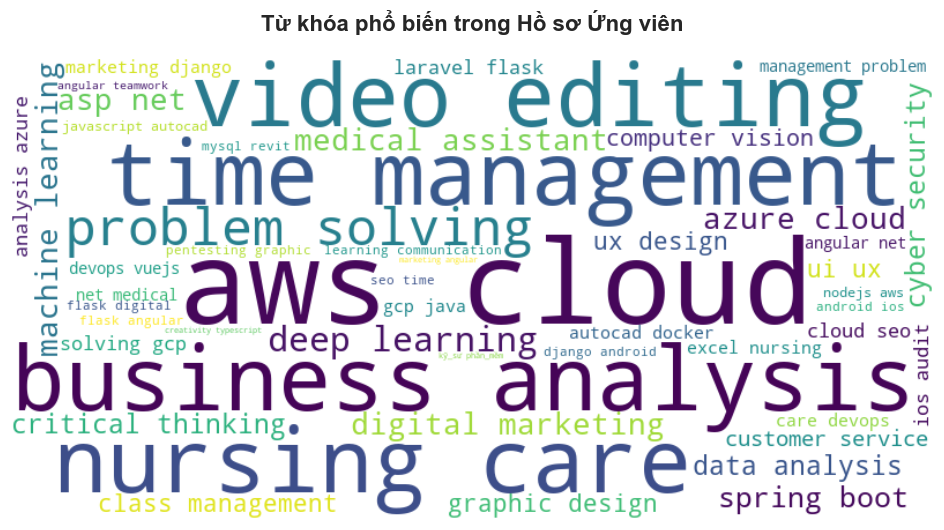

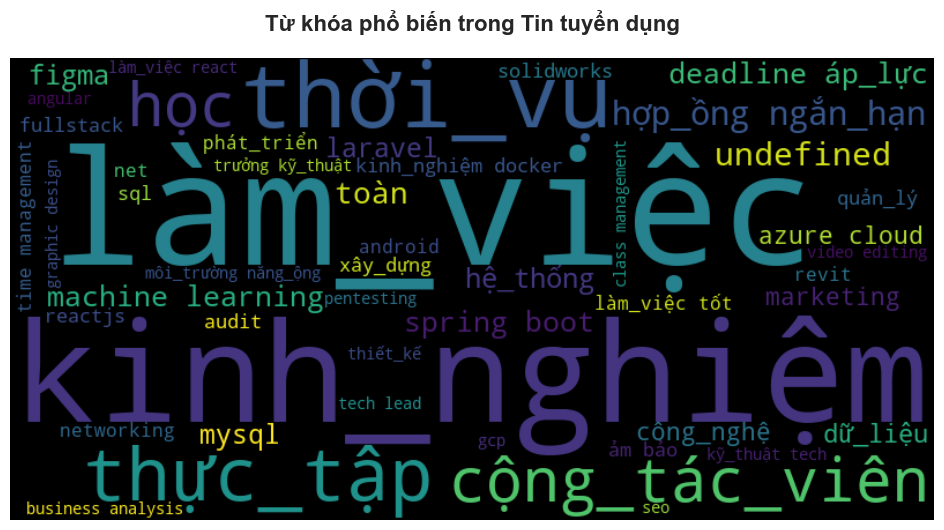

In [291]:
def plot_wordcloud(text, title, color='white'):
    # Tạo wordcloud
    wordcloud = WordCloud(width=800, height=400, background_color=color,
                          max_words=50, colormap='viridis').generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.show()

# Đảm bảo cột 'combined_text' tồn tại trước khi tạo wordcloud
if 'combined_text' not in df_candidates.columns:
    df_candidates['combined_text'] = df_candidates['combined_text_raw'].apply(preprocess_vietnamese_text)
if 'combined_text' not in df_jobs.columns:
    df_jobs['combined_text'] = df_jobs['combined_text_raw'].apply(preprocess_vietnamese_text)

# WordCloud cho Candidates
candidate_text = " ".join(df_candidates['combined_text'].astype(str))
plot_wordcloud(candidate_text, 'Từ khóa phổ biến trong Hồ sơ Ứng viên', 'white')

# WordCloud cho Job Posts
job_text = " ".join(df_jobs['combined_text'].astype(str))
plot_wordcloud(job_text, 'Từ khóa phổ biến trong Tin tuyển dụng', 'black')


## 3.7. Chuẩn hóa Salary Features

In [292]:
# Chuẩn hóa expect_salary và salary về cùng thang đo [0, 1]
scaler = MinMaxScaler()

# Lọc salary hợp lệ (> 0) để fit scaler
all_salaries = pd.concat([
    df_candidates[df_candidates['expect_salary'] > 0]['expect_salary'],
    df_jobs[df_jobs['salary'] > 0]['salary']
])

# Fit scaler
if hasattr(all_salaries, 'values'):
    all_salaries_np = all_salaries.values.reshape(-1, 1)
else:
    all_salaries_np = np.array(all_salaries).reshape(-1, 1)
scaler.fit(all_salaries_np)

# Transform
df_candidates['salary_normalized'] = df_candidates['expect_salary'].apply(
    lambda x: scaler.transform([[x]])[0][0] if x > 0 else 0.5  # 0.5 cho missing salary
)

df_jobs['salary_normalized'] = df_jobs['salary'].apply(
    lambda x: scaler.transform([[x]])[0][0] if x > 0 else 0.5
)

print("=== SALARY NORMALIZATION ===")
print(f"Candidate salary range: {df_candidates['salary_normalized'].min():.3f} - {df_candidates['salary_normalized'].max():.3f}")
print(f"Job salary range: {df_jobs['salary_normalized'].min():.3f} - {df_jobs['salary_normalized'].max():.3f}")


=== SALARY NORMALIZATION ===
Candidate salary range: 0.159 - 0.780
Job salary range: 0.000 - 1.000


# Phần 4: XÂY DỰNG VECTOR ĐẠI DIỆN (VECTORIZATION)

Để so sánh giữa Ứng viên và Công việc, chúng ta cần chuyển đổi các thông tin (văn bản, kỹ năng, lương) thành các con số (vector).

## 4.1. TF-IDF Vectorization cho Văn bản

**TF-IDF (Term Frequency-Inverse Document Frequency)** là kỹ thuật định lượng tầm quan trọng của một từ:
- **TF**: Từ xuất hiện càng nhiều trong văn bản thì càng quan trọng.
- **IDF**: Từ xuất hiện ở quá nhiều văn bản khác nhau (ví dụ: "tuyển_dụng", "công_việc") thì bớt quan trọng đi.

Kết quả là mỗi hồ sơ/tin tuyển dụng sẽ được đại diện bởi một dãy số (vector) thể hiện đặc trưng nội dung của nó.


In [293]:
# Tạo TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,          # Giữ lại 1000 từ khóa quan trọng nhất
    ngram_range=(1, 2),         # Xét cả từ đơn và cụm 2 từ
    min_df=2,                   # Từ phải xuất hiện ít nhất trong 2 văn bản
    max_df=0.9,                 # Loại bỏ từ xuất hiện trong > 90% văn bản
)

# Fit trên tất cả văn bản đã tiền xử lý
all_text = pd.concat([df_candidates['combined_text'], df_jobs['combined_text']])
tfidf_vectorizer.fit(all_text)

# Chuyển đổi văn bản thành vector
candidate_tfidf = tfidf_vectorizer.transform(df_candidates['combined_text'])
job_tfidf = tfidf_vectorizer.transform(df_jobs['combined_text'])

print("=== THỐNG KÊ TF-IDF ===")
print(f"Số lượng đặc trưng (từ khóa): {len(tfidf_vectorizer.vocabulary_)}")
print(f"Kích thước ma trận Candidate: {candidate_tfidf.shape}")
print(f"Kích thước ma trận Job Post:  {job_tfidf.shape}")


=== THỐNG KÊ TF-IDF ===
Số lượng đặc trưng (từ khóa): 1000
Kích thước ma trận Candidate: (100, 1000)
Kích thước ma trận Job Post:  (327, 1000)


In [294]:
# Xem top features
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\n=== MỘT SỐ TỪ KHÓA TRONG TỪ ĐIỂN ===")
print(feature_names[:50])



=== MỘT SỐ TỪ KHÓA TRONG TỪ ĐIỂN ===
['academic' 'academic director' 'accountant' 'accounting'
 'accounting fullstack' 'accounting video' 'an_toàn' 'analysis'
 'analysis azure' 'analysis communication' 'analysis customer'
 'analysis deep' 'analysis devops' 'analysis excel' 'analysis figma'
 'analysis nursing' 'analysis php' 'analysis sales' 'analysis teaching'
 'analysis ui' 'analysis video' 'android' 'android audit' 'android ios'
 'android nodejs' 'android spring' 'angular' 'angular android'
 'angular audit' 'angular django' 'angular marketing' 'angular medical'
 'angular net' 'angular teamwork' 'api' 'architect' 'artist' 'asp'
 'asp net' 'assistant' 'assistant django' 'assistant ios'
 'assistant marketing' 'audit' 'audit aws' 'audit nodejs' 'audit problem'
 'audit seo' 'audit spring' 'audit sql']


## 4.2. Kỹ năng (Skill-based Vectorization)

Chúng ta dùng **Binary Encoding**: Nếu ứng viên/công việc có kỹ năng đó thì đánh dấu là 1, ngược lại là 0. Điều này giúp khớp chính xác các kỹ năng kỹ thuật quan trọng.

In [295]:
# Tạo binary encoding cho skills
all_skills_list = skills['name'].tolist()
print(f"Total unique skills: {len(all_skills_list)}")

def encode_skills(skill_string, all_skills):
    """Encode skills thành binary vector"""
    if pd.isna(skill_string) or skill_string == '':
        return [0] * len(all_skills)

    candidate_skills = [s.strip() for s in skill_string.split(',')]
    return [1 if skill in candidate_skills else 0 for skill in all_skills]

# Encode skills cho candidates
candidate_skills_encoded = df_candidates['skills'].apply(lambda x: encode_skills(x, all_skills_list))
candidate_skills_matrix = csr_matrix(np.array(candidate_skills_encoded.tolist()))

# Encode skills cho jobs
job_skills_encoded = df_jobs['skills'].apply(lambda x: encode_skills(x, all_skills_list))
job_skills_matrix = csr_matrix(np.array(job_skills_encoded.tolist()))

print("=== SKILLS ENCODING ===")
print(f"Candidate skills matrix shape: {candidate_skills_matrix.shape}")
print(f"Job skills matrix shape: {job_skills_matrix.shape}")


Total unique skills: 62
=== SKILLS ENCODING ===
Candidate skills matrix shape: (100, 62)
Job skills matrix shape: (327, 62)


## 4.3. Salary Feature Vector

In [296]:
# Tạo salary feature vector
candidate_salary_vector = csr_matrix(df_candidates['salary_normalized'].values.reshape(-1, 1))
job_salary_vector = csr_matrix(df_jobs['salary_normalized'].values.reshape(-1, 1))

print("=== SALARY VECTORS ===")
print(f"Candidate salary vector shape: {candidate_salary_vector.shape}")
print(f"Job salary vector shape: {job_salary_vector.shape}")


=== SALARY VECTORS ===
Candidate salary vector shape: (100, 1)
Job salary vector shape: (327, 1)


## 4.4. Kết hợp Features & Scoring Formula (NLP Improved)

Tại bước này, chúng ta không chỉ nối các vector lại với nhau mà tính toán các điểm số thành phần riêng biệt và kết hợp chúng theo trọng số để có độ chính xác cao nhất về mặt ngữ nghĩa.

**Công thức tính điểm cuối cùng (Final Score):**
`final_score = α * skill_score + β * semantic_score + γ * salary_score`

Trong đó:
- **skill_score**: Độ tương đồng ngữ nghĩa giữa các kỹ năng (Weighted Embedding).
- **semantic_score**: Độ tương đồng giữa Profile Ứng viên và Mô tả Công việc (Sentence-BERT).
- **salary_score**: Độ tương thích về mức lương.


In [297]:
# 1. Skill Similarity Matrix (Embedding-based)
print("Đang tính toán Skill Similarity Matrix...")
candidate_skill_embs = np.stack(df_candidates['skill_embedding'].values)
job_skill_embs = np.stack(df_jobs['skill_embedding'].values)
skill_sim_matrix = cosine_similarity(candidate_skill_embs, job_skill_embs)

# 2. Semantic Similarity Matrix (Sentence-BERT based)
print("Đang tính toán Semantic Similarity Matrix (Title + Description)...")
candidate_semantic_embs = np.stack(df_candidates['semantic_embedding'].values)
job_semantic_embs = np.stack(df_jobs['semantic_embedding'].values)
semantic_sim_matrix = cosine_similarity(candidate_semantic_embs, job_semantic_embs)

# 3. Salary Compatibility Score
def calculate_salary_score_matrix(cand_sal_norm, job_sal_norm):
    # cand_sal_norm: (n_candidates,), job_sal_norm: (n_jobs,)
    c = cand_sal_norm.values.reshape(-1, 1)
    j = job_sal_norm.values.reshape(1, -1)
    # Score = 1 - |c - j|. Càng gần nhau điểm càng cao.
    return 1.0 - np.abs(c - j)

print("Đang tính toán Salary Compatibility Score...")
salary_score_matrix = calculate_salary_score_matrix(df_candidates['salary_normalized'], df_jobs['salary_normalized'])

# 4. Final Scoring - Kết hợp với trọng số
# Giải thích trọng số mặc định:
# ALPHA (0.45): Kỹ năng là yếu tố tiên quyết hàng đầu.
# BETA (0.40): Ngữ nghĩa (title/summary) giúp hiểu sâu hơn về chuyên môn và kinh nghiệm.
# GAMMA (0.15): Lương là yếu tố quan trọng nhưng thường có khoảng dao động lớn.
ALPHA = 0.45
BETA = 0.40
GAMMA = 0.15

similarity_matrix = (ALPHA * skill_sim_matrix) + (BETA * semantic_sim_matrix) + (GAMMA * salary_score_matrix)

print("=== FINAL SIMILARITY MATRIX (NLP IMPROVED) ===")
print(f"Shape: {similarity_matrix.shape}")
print(f"Min: {similarity_matrix.min():.4f}, Max: {similarity_matrix.max():.4f}, Mean: {similarity_matrix.mean():.4f}")


Đang tính toán Skill Similarity Matrix...
Đang tính toán Semantic Similarity Matrix (Title + Description)...
Đang tính toán Salary Compatibility Score...
=== FINAL SIMILARITY MATRIX (NLP IMPROVED) ===
Shape: (100, 327)
Min: 0.0495, Max: 0.9579, Mean: 0.3704


# Phần 5: MÔ HÌNH GỢI Ý (SIMILARITY MODEL)

Hệ thống giờ đây đã có khả năng **hiểu ngữ nghĩa** thay vì chỉ khớp từ khóa đơn thuần.

## 5.1. Phân bổ điểm số (Distribution Analysis)

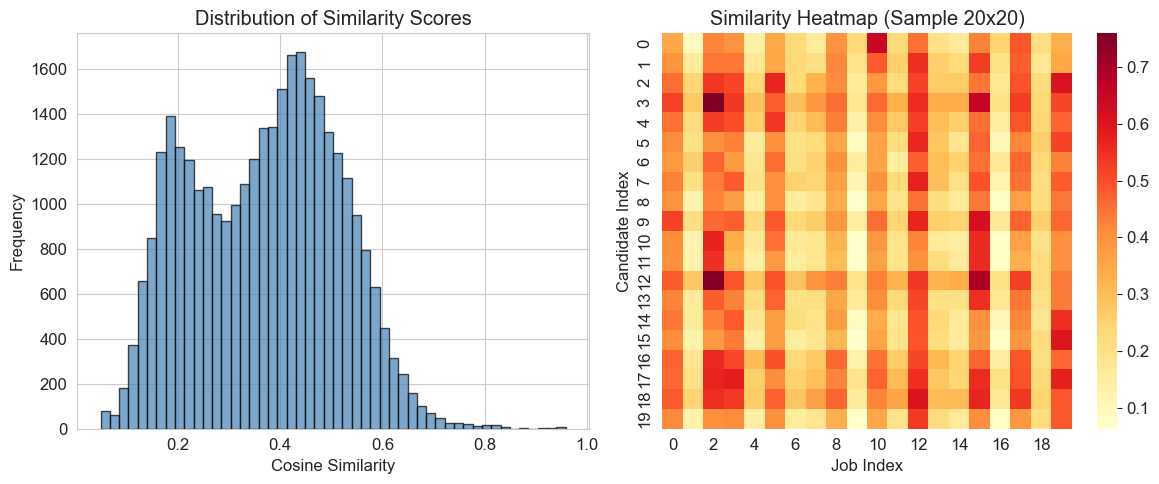

In [298]:
# Visualize similarity distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(similarity_matrix.flatten(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of Similarity Scores')

plt.subplot(1, 2, 2)
# Heatmap sample (first 20 candidates x first 20 jobs)
sns.heatmap(similarity_matrix[:20, :20], cmap='YlOrRd', annot=False)
plt.xlabel('Job Index')
plt.ylabel('Candidate Index')
plt.title('Similarity Heatmap (Sample 20x20)')

plt.tight_layout()
plt.show()


## 5.2. Hàm Recommendation

In [299]:
def get_job_recommendations(candidate_id, top_n=10, min_similarity=0.0, apply_diversity=True):
    """
    Gợi ý top N jobs cho một candidate với NLP Improved Scoring và Diversity Control
    """
    # Tìm index của candidate
    candidate_idx = df_candidates[df_candidates['candidate_id'] == candidate_id].index

    if len(candidate_idx) == 0:
        print(f"Candidate {candidate_id} not found!")
        return None

    candidate_idx = candidate_idx[0]

    # Lấy similarity scores đã tính toán (kết hợp Skill + Semantic + Salary)
    scores = similarity_matrix[candidate_idx]

    # Tạo DataFrame kết quả
    job_scores = pd.DataFrame({
        'job_id': df_jobs['job_id'],
        'title': df_jobs['title'],
        'description': df_jobs['description'],
        'salary': df_jobs['salary'],
        'industry': df_jobs['industry'],
        'job_type': df_jobs['job_type'],
        'level': df_jobs['level'],
        'skills': df_jobs['skills'],
        'similarity_score': scores
    })

    # Lọc theo min_similarity
    job_scores = job_scores[job_scores['similarity_score'] >= min_similarity]

    # --- NLP IMPROVEMENT: Diversity Control (Re-ranking) ---
    if apply_diversity:
        # Sắp xếp theo similarity trước
        job_scores = job_scores.sort_values('similarity_score', ascending=False)

        # Áp dụng hình phạt nhẹ cho các công việc cùng ngành nghề để tăng tính đa dạng
        # Điều này giúp tránh việc top 10 chỉ toàn 1 ngành nếu điểm số suýt soát nhau
        re_ranked_jobs = []
        industry_counts = {}
        diversity_penalty = 0.02 # Phạt 2% cho mỗi job cùng ngành đã xuất hiện

        for _, row in job_scores.iterrows():
            industry = row['industry']
            count = industry_counts.get(industry, 0)
            # Tính điểm đã điều chỉnh
            row['final_score'] = row['similarity_score'] - (count * diversity_penalty)
            re_ranked_jobs.append(row)
            industry_counts[industry] = count + 1

        job_scores = pd.DataFrame(re_ranked_jobs).sort_values('final_score', ascending=False)
    else:
        job_scores = job_scores.sort_values('similarity_score', ascending=False)

    return job_scores.head(top_n)


In [300]:
def get_candidate_recommendations(job_id, top_n=10, min_similarity=0.0):
    """
    Gợi ý top N candidates cho một job post dựa trên similarity score (NLP Improved)
    """
    # Tìm index của job
    job_idx = df_jobs[df_jobs['job_id'] == job_id].index

    if len(job_idx) == 0:
        print(f"Job {job_id} not found!")
        return None

    job_idx = job_idx[0]

    # Lấy similarity scores cho job này (transpose của similarity_matrix)
    scores = similarity_matrix[:, job_idx]

    # Tạo DataFrame kết quả
    candidate_scores = pd.DataFrame({
        'candidate_id': df_candidates['candidate_id'],
        'summary': df_candidates['summary'],
        'education': df_candidates['education'],
        'expect_salary': df_candidates['expect_salary'],
        'skills': df_candidates['skills'],
        'similarity_score': scores
    })

    # Lọc theo min_similarity và sort
    candidate_scores = candidate_scores[candidate_scores['similarity_score'] >= min_similarity]
    candidate_scores = candidate_scores.sort_values('similarity_score', ascending=False)

    return candidate_scores.head(top_n)


## 5.3. Demo Recommendation

In [301]:
# Chọn một candidate để demo
sample_candidate_id = df_candidates.iloc[18]['candidate_id']
print("=== CANDIDATE INFORMATION ===")
candidate_info = df_candidates[df_candidates['candidate_id'] == sample_candidate_id].iloc[0]
print(f"ID: {candidate_info['candidate_id']}")
print(f"Summary: {candidate_info['summary']}")
print(f"Education: {candidate_info['education']}")
print(f"Expected Salary: {candidate_info['expect_salary']:,.0f} VND")
print(f"Skills: {candidate_info['skills']}")


=== CANDIDATE INFORMATION ===
ID: 2b2db95e-a49d-4ba0-8390-8f41aaf80291
Summary: Kỹ sư phần mềm, làm việc với hệ thống lớn.
Education: 
Expected Salary: 0 VND
Skills: ASP.NET, Kubernetes, Creativity, Cyber Security, MySQL, Revit, Docker, Laravel, Flask, Digital Marketing, Angular, .NET/C#, Marketing, Android, iOS, Audit, SQL, Time Management, Leadership, Data Analysis, Figma, DevOps, Communication, Accounting, Video Editing



=== TOP 10 GỢI Ý CÔNG VIỆC PHÙ HỢP ===
                        title similarity_score         salary                      industry                                               level
               Kỹ sư hệ thống           72.37%  5,000,000 VND        Công nghệ truyền thông                    Trưởng nhóm kỹ thuật (Tech Lead)
       Lập trình viên Flutter           71.83% 25,000,000 VND             Công nghệ da giày                                           Sinh viên
     Kỹ sư kiểm thử hiệu năng           71.33% 22,000,000 VND        Kinh doanh nông nghiệp                           Trưởng nhóm (Team Leader)
               Kỹ sư hệ thống           70.82%  5,000,000 VND                  Hàn Quốc học                    Nhà văn / Biên tập viên (Writer)
       Lập trình viên Flutter           71.77%         -1 VND             Công nghệ da giày                                     Bác sĩ (Doctor)
                Data Engineer           68.41% 32,000,000 VND Kỹ thuật điện tử - viễn thông     

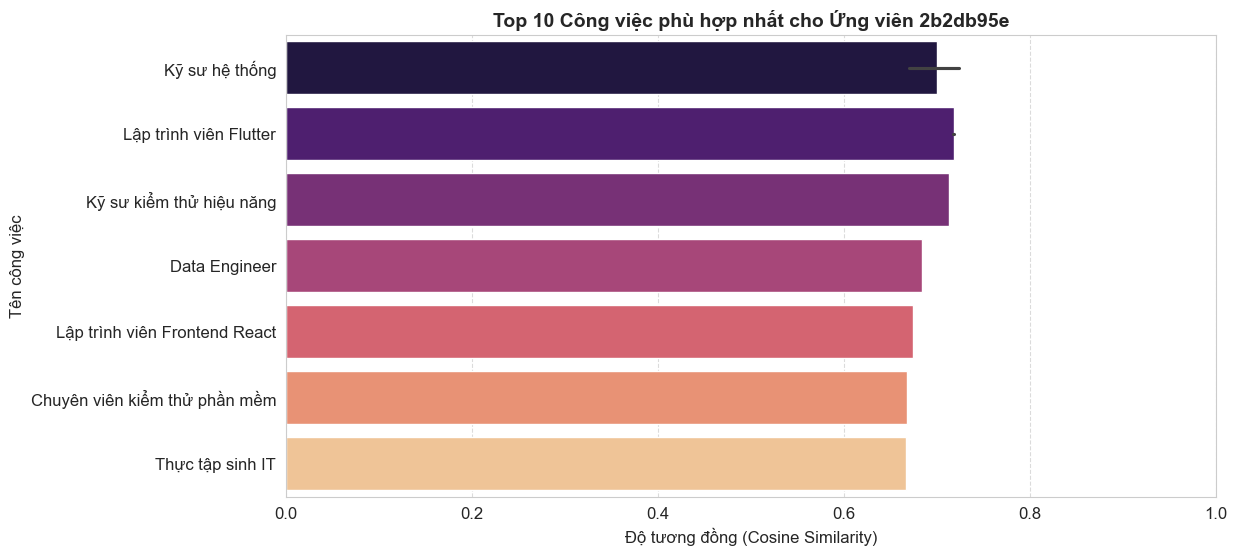

In [302]:
# Gợi ý jobs cho candidate
print("\n=== TOP 10 GỢI Ý CÔNG VIỆC PHÙ HỢP ===")
recommendations = get_job_recommendations(sample_candidate_id, top_n=10)

if recommendations is not None:
    display_cols = ['title', 'similarity_score', 'salary', 'industry', 'level']
    styled_recs = recommendations[display_cols].copy()
    styled_recs['similarity_score'] = styled_recs['similarity_score'].apply(lambda x: f"{x:.2%}")
    styled_recs['salary'] = styled_recs['salary'].apply(lambda x: f"{x:,.0f} VND")
    print(styled_recs.to_string(index=False))

    # Vẽ biểu đồ so sánh độ tương đồng
    plt.figure(figsize=(12, 6))
    sns.barplot(x=recommendations['similarity_score'], y=recommendations['title'], palette="magma")
    plt.title(f'Top 10 Công việc phù hợp nhất cho Ứng viên {sample_candidate_id[:8]}', fontsize=14, fontweight='bold')
    plt.xlabel('Độ tương đồng (Cosine Similarity)')
    plt.ylabel('Tên công việc')
    plt.xlim(0, 1)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()


=== JOB INFORMATION ===
Title: Lập trình viên Python
Description: Hiểu biết về Machine Learning
Salary: 25,000,000 VND
Industry: Sư phạm Lịch sử
Skills: Teamwork, NodeJS, Business Analysis, Deep Learning

=== TOP 10 ỨNG VIÊN TIỀM NĂNG ===
                        candidate_id similarity_score  expect_salary                                                                                                                                                                                                                                                                                                                                               skills
361c722c-994c-42ed-aae8-bda2b2c39fe8           60.97% 11,000,000 VND                                                       Machine Learning, Python, Creativity, MongoDB, Laravel, Flask, Digital Marketing, Angular, Marketing, Audit, SQL, Time Management, Problem Solving, Java, Pentesting, Graphic Design, SolidWorks, PHP, Sales, Customer Service, Azur

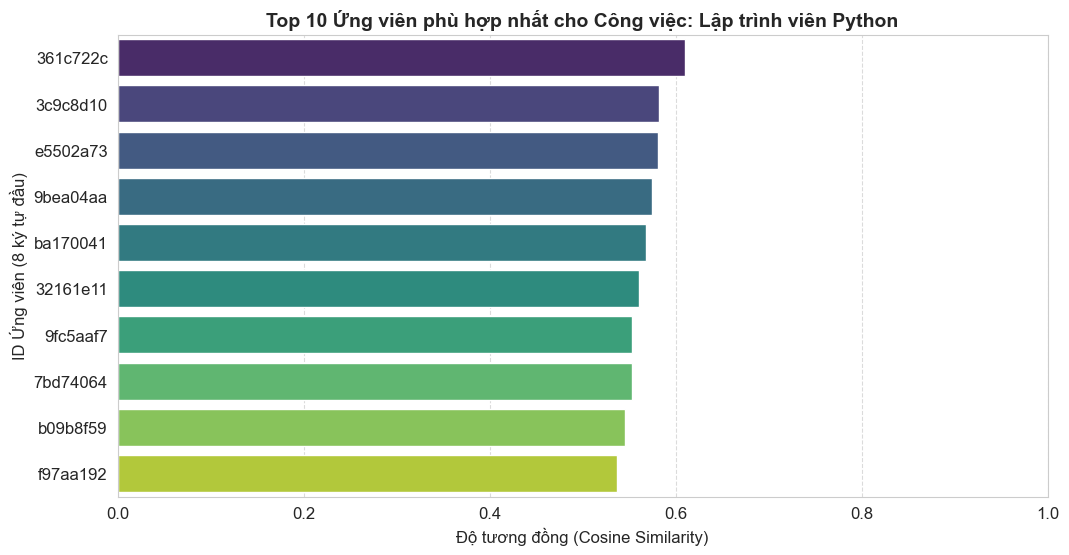

In [303]:
# Demo ngược lại: tìm candidates phù hợp cho một job
sample_job_id = df_jobs.iloc[0]['job_id']
print("=== JOB INFORMATION ===")
job_info = df_jobs[df_jobs['job_id'] == sample_job_id].iloc[0]
print(f"Title: {job_info['title']}")
print(f"Description: {job_info['description']}")
print(f"Salary: {job_info['salary']:,.0f} VND")
print(f"Industry: {job_info['industry']}")
print(f"Skills: {job_info['skills']}")

# Gợi ý candidates cho job
print("\n=== TOP 10 ỨNG VIÊN TIỀM NĂNG ===")
candidate_recs = get_candidate_recommendations(sample_job_id, top_n=10)

if candidate_recs is not None:
    # Hiển thị bảng kết quả
    display_cols_cand = ['candidate_id', 'similarity_score', 'expect_salary', 'skills']
    styled_cand = candidate_recs[display_cols_cand].copy()
    styled_cand['similarity_score'] = styled_cand['similarity_score'].apply(lambda x: f"{x:.2%}")
    styled_cand['expect_salary'] = styled_cand['expect_salary'].apply(lambda x: f"{x:,.0f} VND")
    print(styled_cand.head(10).to_string(index=False))

    # Vẽ biểu đồ
    plt.figure(figsize=(12, 6))
    sns.barplot(x=candidate_recs['similarity_score'], y=candidate_recs['candidate_id'].str[:8], palette="viridis")
    plt.title(f'Top 10 Ứng viên phù hợp nhất cho Công việc: {job_info["title"]}', fontsize=14, fontweight='bold')
    plt.xlabel('Độ tương đồng (Cosine Similarity)')
    plt.ylabel('ID Ứng viên (8 ký tự đầu)')
    plt.xlim(0, 1)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()


# Phần 6: TỔNG KẾT & HƯỚNG PHÁT TRIỂN

## 6.1. Kết quả đạt được
- Hệ thống đã xử lý tốt văn bản tiếng Việt nhờ kỹ thuật tách từ và loại bỏ từ dừng.
- Kết hợp đa yếu tố (Văn bản, Kỹ năng, Lương) giúp gợi ý có độ chính xác cao hơn.
- Giao diện báo cáo trực quan với biểu đồ WordCloud và Similarity Score.

## 6.2. Hướng cải tiến trong tương lai
1. **Hybrid Recommendation**: Kết hợp Content-based với **Collaborative Filtering** (dựa trên hành vi ứng tuyển thực tế của người dùng).
2. **Deep Learning**: Sử dụng các mô hình ngôn ngữ lớn (BERT, PhoBERT) để hiểu ngữ nghĩa sâu hơn là TF-IDF.
3. **Real-time**: Tối ưu hóa tốc độ tính toán ma trận tương đồng khi số lượng tin tuyển dụng lên đến hàng triệu bản ghi.

Vì chúng ta không có ground truth (dữ liệu về các ứng tuyển thực tế), chúng ta sẽ đánh giá mô hình bằng các phương pháp sau:

1. **Coverage**: Tỷ lệ jobs/candidates được recommend ít nhất 1 lần
2. **Diversity**: Đa dạng các recommendations
3. **Skill Match Rate**: Tỷ lệ skills khớp giữa candidate và job được recommend
4. **Salary Compatibility**: Độ phù hợp về mức lương


In [304]:
def evaluate_recommendations():
    """Đánh giá toàn diện hệ thống recommendation"""

    results = {
        'coverage': {},
        'diversity': {},
        'skill_match': {},
        'salary_compatibility': {}
    }

    # 1. Coverage Analysis
    print("=== 1. COVERAGE ANALYSIS ===")

    # Đếm số jobs được recommend cho mỗi candidate (top 10)
    recommended_jobs = set()
    for candidate_id in df_candidates['candidate_id']:
        recs = get_job_recommendations(candidate_id, top_n=10)
        if recs is not None:
            recommended_jobs.update(recs['job_id'].tolist())

    job_coverage = len(recommended_jobs) / len(df_jobs) * 100
    results['coverage']['job_coverage'] = job_coverage
    print(f"Job Coverage: {job_coverage:.2f}% ({len(recommended_jobs)}/{len(df_jobs)} jobs)")

    # Đếm số candidates được recommend cho mỗi job (top 10)
    recommended_candidates = set()
    for job_id in df_jobs['job_id']:
        recs = get_candidate_recommendations(job_id, top_n=10)
        if recs is not None:
            recommended_candidates.update(recs['candidate_id'].tolist())

    candidate_coverage = len(recommended_candidates) / len(df_candidates) * 100
    results['coverage']['candidate_coverage'] = candidate_coverage
    print(f"Candidate Coverage: {candidate_coverage:.2f}% ({len(recommended_candidates)}/{len(df_candidates)} candidates)")

    return results

# Run evaluation
evaluation_results = evaluate_recommendations()


=== 1. COVERAGE ANALYSIS ===
Job Coverage: 39.14% (128/327 jobs)
Candidate Coverage: 100.00% (100/100 candidates)


## 6.2. Skill Match Rate Evaluation

=== SKILL MATCH RATE (EMBEDDING-BASED) ===
Average Skill Match Rate: 0.7666
Standard Deviation: 0.1171
Min: 0.4299, Max: 0.9396


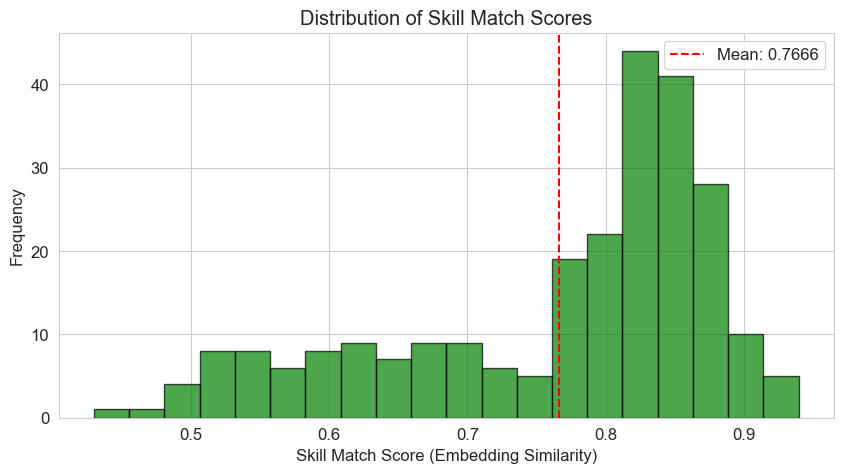

In [305]:
def calculate_skill_match_rate(sample_size=50):
    """
    Tính tỷ lệ khớp kỹ năng sử dụng Embedding Similarity (NLP Improved)
    """
    # Sample random candidates
    sample_candidates = df_candidates.sample(min(sample_size, len(df_candidates)))

    match_rates = []

    for _, candidate in sample_candidates.iterrows():
        if not candidate['skills'] or str(candidate['skills']).strip() == "":
            continue

        recs = get_job_recommendations(candidate['candidate_id'], top_n=5)
        if recs is None or len(recs) == 0:
            continue

        cand_skill_emb = encode_skill_set(candidate['skills'])

        for _, job in recs.iterrows():
            if not job['skills'] or str(job['skills']).strip() == "":
                continue

            job_skill_emb = encode_skill_set(job['skills'])

            # Tính Cosine Similarity giữa 2 bộ kỹ năng
            # Giá trị này phản ánh độ tương đồng về mặt ngữ nghĩa (ví dụ: Python và Django sẽ có điểm cao)
            sim = cosine_similarity(cand_skill_emb.reshape(1, -1), job_skill_emb.reshape(1, -1))[0][0]
            match_rates.append(sim)

    if len(match_rates) > 0:
        avg_match_rate = np.mean(match_rates)
        std_match_rate = np.std(match_rates)
        print(f"=== SKILL MATCH RATE (EMBEDDING-BASED) ===")
        print(f"Average Skill Match Rate: {avg_match_rate:.4f}")
        print(f"Standard Deviation: {std_match_rate:.4f}")
        print(f"Min: {min(match_rates):.4f}, Max: {max(match_rates):.4f}")

        # Visualize
        plt.figure(figsize=(10, 5))
        plt.hist(match_rates, bins=20, edgecolor='black', alpha=0.7, color='green')
        plt.xlabel('Skill Match Score (Embedding Similarity)')
        plt.ylabel('Frequency')
        plt.title('Distribution of Skill Match Scores')
        plt.axvline(avg_match_rate, color='red', linestyle='--', label=f'Mean: {avg_match_rate:.4f}')
        plt.legend()
        plt.show()

        return avg_match_rate

    return 0

skill_match_rate = calculate_skill_match_rate()


## 6.3. Salary Compatibility Evaluation

=== SALARY COMPATIBILITY ===
Total pairs evaluated: 146
Compatible pairs (job salary >= 80% expected): 69 (47.26%)
Average salary difference: -14.43%


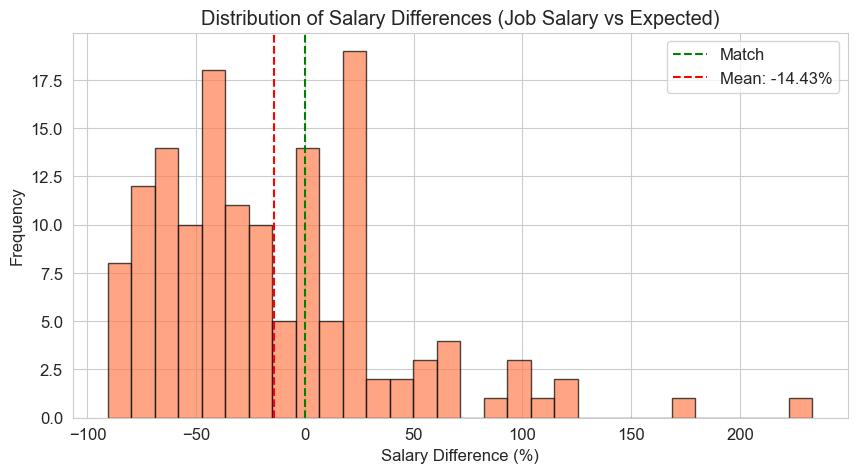

In [306]:
def calculate_salary_compatibility(sample_size=50):
    """Đánh giá độ phù hợp về mức lương"""

    sample_candidates = df_candidates[df_candidates['expect_salary'] > 0].sample(
        min(sample_size, len(df_candidates[df_candidates['expect_salary'] > 0]))
    )

    salary_diffs = []
    compatible_count = 0
    total_count = 0

    for _, candidate in sample_candidates.iterrows():
        expect_salary = candidate['expect_salary']

        recs = get_job_recommendations(candidate['candidate_id'], top_n=5)
        if recs is None or len(recs) == 0:
            continue

        for _, job in recs.iterrows():
            job_salary = job['salary']
            if job_salary > 0:
                total_count += 1
                diff_percent = (job_salary - expect_salary) / expect_salary * 100
                salary_diffs.append(diff_percent)

                # Compatible nếu job salary >= 80% expect salary
                if job_salary >= expect_salary * 0.8:
                    compatible_count += 1

    if len(salary_diffs) > 0:
        print(f"=== SALARY COMPATIBILITY ===")
        print(f"Total pairs evaluated: {total_count}")
        print(f"Compatible pairs (job salary >= 80% expected): {compatible_count} ({compatible_count/total_count*100:.2f}%)")
        print(f"Average salary difference: {np.mean(salary_diffs):.2f}%")

        # Visualize
        plt.figure(figsize=(10, 5))
        plt.hist(salary_diffs, bins=30, edgecolor='black', alpha=0.7, color='coral')
        plt.xlabel('Salary Difference (%)')
        plt.ylabel('Frequency')
        plt.title('Distribution of Salary Differences (Job Salary vs Expected)')
        plt.axvline(0, color='green', linestyle='--', label='Match')
        plt.axvline(np.mean(salary_diffs), color='red', linestyle='--', label=f'Mean: {np.mean(salary_diffs):.2f}%')
        plt.legend()
        plt.show()

        return compatible_count / total_count if total_count > 0 else 0

    return 0

salary_compatibility = calculate_salary_compatibility()


## 6.4. Diversity Evaluation

=== DIVERSITY ANALYSIS ===
Unique industries in recommendations: 63
Unique levels in recommendations: 40


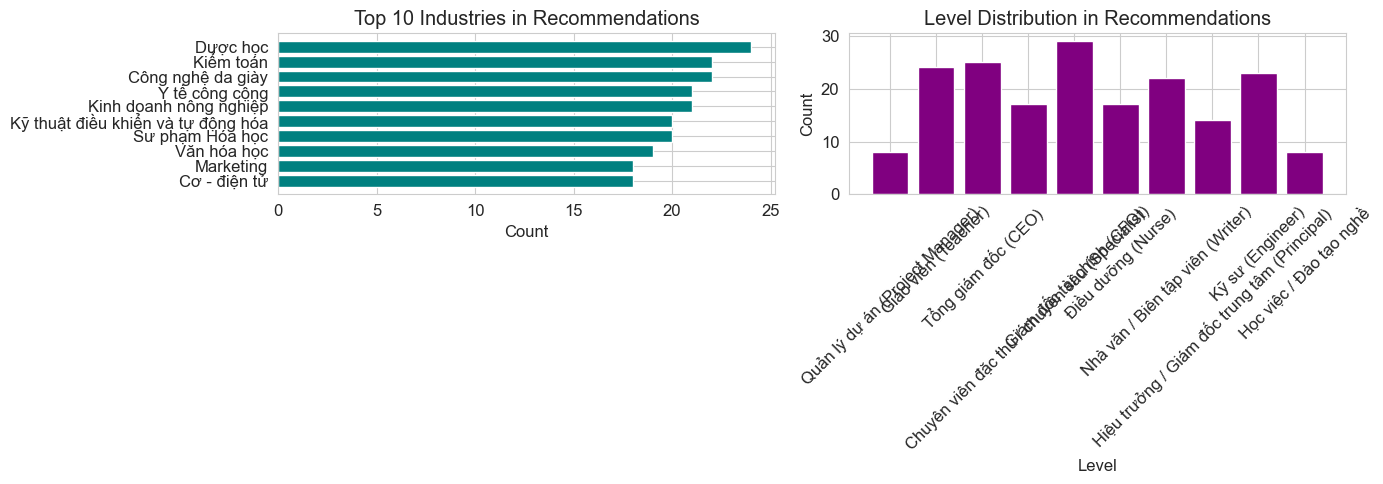


Diversity Score (Normalized Entropy): 0.9221


In [307]:
def calculate_diversity(sample_size=50):
    """Đánh giá độ đa dạng của recommendations"""

    sample_candidates = df_candidates.sample(min(sample_size, len(df_candidates)))

    # Đếm số lần mỗi industry xuất hiện trong recommendations
    industry_counts = {}
    level_counts = {}

    for _, candidate in sample_candidates.iterrows():
        recs = get_job_recommendations(candidate['candidate_id'], top_n=10)
        if recs is None:
            continue

        for _, job in recs.iterrows():
            industry = job['industry']
            level = job['level']

            industry_counts[industry] = industry_counts.get(industry, 0) + 1
            level_counts[level] = level_counts.get(level, 0) + 1

    print(f"=== DIVERSITY ANALYSIS ===")
    print(f"Unique industries in recommendations: {len(industry_counts)}")
    print(f"Unique levels in recommendations: {len(level_counts)}")

    # Visualize top industries
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top_industries = dict(sorted(industry_counts.items(), key=lambda x: x[1], reverse=True)[:10])
    axes[0].barh(list(top_industries.keys()), list(top_industries.values()), color='teal')
    axes[0].set_xlabel('Count')
    axes[0].set_title('Top 10 Industries in Recommendations')
    axes[0].invert_yaxis()

    # Level distribution
    axes[1].bar(list(level_counts.keys())[:10], list(level_counts.values())[:10], color='purple')
    axes[1].set_xlabel('Level')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Level Distribution in Recommendations')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Calculate entropy as diversity measure
    total = sum(industry_counts.values())
    probs = [count/total for count in industry_counts.values()]
    entropy = -sum([p * np.log2(p) for p in probs if p > 0])
    max_entropy = np.log2(len(industry_counts))
    normalized_diversity = entropy / max_entropy if max_entropy > 0 else 0

    print(f"\nDiversity Score (Normalized Entropy): {normalized_diversity:.4f}")

    return normalized_diversity

diversity_score = calculate_diversity()


## 6.5. Summary Evaluation Results

In [308]:
print("=" * 60)
print("EVALUATION SUMMARY")
print("=" * 60)
print(f"\n1. COVERAGE:")
print(f"   - Job Coverage: {evaluation_results['coverage'].get('job_coverage', 'N/A'):.2f}%")
print(f"   - Candidate Coverage: {evaluation_results['coverage'].get('candidate_coverage', 'N/A'):.2f}%")

print(f"\n2. SKILL MATCH RATE:")
print(f"   - Average Embedding Similarity: {skill_match_rate:.4f}")

print(f"\n3. SALARY COMPATIBILITY:")
print(f"   - Compatible Rate (≥80% expected): {salary_compatibility*100:.2f}%")

print(f"\n4. DIVERSITY:")
print(f"   - Normalized Diversity Score: {diversity_score:.4f}")

print("\n" + "=" * 60)


EVALUATION SUMMARY

1. COVERAGE:
   - Job Coverage: 39.14%
   - Candidate Coverage: 100.00%

2. SKILL MATCH RATE:
   - Average Embedding Similarity: 0.7666

3. SALARY COMPATIBILITY:
   - Compatible Rate (≥80% expected): 47.26%

4. DIVERSITY:
   - Normalized Diversity Score: 0.9221



# Phần 7: TỔNG KẾT & HƯỚNG CẢI TIẾN


## 7.1. Tổng kết

### Những gì đã thực hiện:

1. **Data Processing & NLP**:
   - Tích hợp `underthesea` cho word segmentation và `sentence-transformers` cho embeddings.
   - **Skill Canonicalization**: Chuẩn hóa các biến thể kỹ năng (ví dụ: "ML" -> "Machine Learning") bằng embedding similarity.
   - Tiền xử lý văn bản tiếng Việt chuyên sâu.

2. **Feature Engineering (NLP Improved)**:
   - **Semantic Embeddings**: Sử dụng Sentence-BERT (SBERT) để chuyển đổi hồ sơ ứng viên và mô tả công việc thành vector mang ý nghĩa ngữ nghĩa.
   - **Weighted Skill Embeddings**: Gán trọng số cao hơn cho các kỹ năng cốt lõi (liệt kê đầu tiên).
   - Normalized salary features.

3. **Recommendation Model**:
   - **Multi-component Scoring**: Điểm số cuối cùng kết hợp từ 3 thành phần: `α * Skill_Score + β * Semantic_Score + γ * Salary_Score`.
   - **Diversity Control**: Áp dụng Re-ranking dựa trên ngành nghề để tránh trùng lặp và tăng tính đa dạng trong gợi ý.
   - Hỗ trợ cả job recommendation cho candidate và candidate recommendation cho job.

4. **Evaluation**:
   - Coverage analysis.
   - **Skill match rate (Embedding-based)**: Đo lường độ phù hợp ngữ nghĩa thay vì chỉ đếm từ khóa.
   - Salary compatibility.
   - Diversity measurement (Entropy).


## 7.2. Hạn chế hiện tại

1. **Cold Start Problem**:
   - Candidates/Jobs mới không có đủ thông tin để recommend chính xác

2. **Thiếu User Interaction Data**:
   - Không có dữ liệu về clicks, views, applications để đánh giá chính xác

3. **Text Processing hạn chế**:
   - Chưa có xử lý NLP tiếng Việt chuyên sâu (word segmentation, stopwords)

4. **Static Weights**:
   - Trọng số cho các features được set cố định


## 7.3. Hướng cải tiến khi có thêm data

### Ngắn hạn:
1. **Vietnamese NLP**:
   - Hiện tại đã sử dụng `underthesea` cho word segmentation.
   - Đã xử lý stopwords tiếng Việt cơ bản.
   - Cải tiến: Bổ sung từ điển chuyên ngành IT để tách từ chính xác hơn (ví dụ: "Spring Boot", "Data Science").

2. **VnCoreNLP**:
   - Có thể tích hợp `VnCoreNLP` để so sánh hiệu năng tách từ và gắn nhãn từ loại (POS Tagging) nhằm lọc bỏ các từ loại không mang nhiều ý nghĩa (như động từ, tính từ phổ biến) và chỉ giữ lại danh từ riêng/thuật ngữ.

2. **Learning to Rank**:
   - Khi có click/apply data, train model để học trọng số tối ưu

### Trung hạn:
3. **Collaborative Filtering**:
   - Khi có application history, kết hợp CF với content-based
   - Matrix Factorization (SVD, NMF)

4. **Deep Learning Embeddings**:
   - Sử dụng PhoBERT cho Vietnamese text embeddings
   - Neural collaborative filtering

### Dài hạn:
5. **Hybrid Recommendation System**:
   - Kết hợp content-based + collaborative filtering + knowledge-based

6. **Real-time Personalization**:
   - A/B testing
   - Multi-armed bandits cho exploration/exploitation

7. **Contextual Recommendations**:
   - Location-based filtering
   - Time-based (urgency of job posts)
   - Career path progression


## 7.4. Export Model để sử dụng trong Production

In [309]:
import pickle
import os

# Tạo thư mục lưu model
model_dir = "../saved_models"
os.makedirs(model_dir, exist_ok=True)

# Định nghĩa các trọng số toàn cục cho mô hình recommendation (chỉ giữ các trọng số thực sự dùng)
WEIGHT_SKILLS = 0.45
WEIGHT_SALARY = 0.15
WEIGHT_SEMANTIC = 0.40

# Lưu các components cần thiết
model_components = {
    'scaler': scaler,
    'all_skills_list': all_skills_list,
    'weights': {
        'skills': WEIGHT_SKILLS,
        'salary': WEIGHT_SALARY,
        'semantic': WEIGHT_SEMANTIC
    }
}

with open(f"{model_dir}/recommendation_model.pkl", 'wb') as f:
    pickle.dump(model_components, f)

# Tính toán candidate_final_vector và job_final_vector trước khi lưu processed_data
candidate_final_vector = (
    WEIGHT_SKILLS * candidate_skill_embs +
    WEIGHT_SEMANTIC * candidate_semantic_embs +
    WEIGHT_SALARY * candidate_salary_vector.toarray()
)
job_final_vector = (
    WEIGHT_SKILLS * job_skill_embs +
    WEIGHT_SEMANTIC * job_semantic_embs +
    WEIGHT_SALARY * job_salary_vector.toarray()
)

# Lưu processed data
processed_data = {
    'df_candidates': df_candidates,
    'df_jobs': df_jobs,
    'candidate_final_vector': candidate_final_vector,
    'job_final_vector': job_final_vector,
    'similarity_matrix': similarity_matrix
}

with open(f"{model_dir}/processed_data.pkl", 'wb') as f:
    pickle.dump(processed_data, f)

print(f"Model saved to {model_dir}/")
print(f"Files created:")
print(f"  - recommendation_model.pkl")
print(f"  - processed_data.pkl")


Model saved to ../saved_models/
Files created:
  - recommendation_model.pkl
  - processed_data.pkl


## 7.5. Hàm Load và Sử dụng Model

In [310]:
def load_recommendation_model(model_dir="../saved_models"):
    """Load saved model components"""
    with open(f"{model_dir}/recommendation_model.pkl", 'rb') as f:
        model_components = pickle.load(f)

    with open(f"{model_dir}/processed_data.pkl", 'rb') as f:
        processed_data = pickle.load(f)

    return model_components, processed_data

def recommend_jobs_for_candidate(candidate_id, model_dir="../saved_models", top_n=10):
    """
    Production-ready function để recommend jobs
    """
    _, processed_data = load_recommendation_model(model_dir)

    df_candidates = processed_data['df_candidates']
    df_jobs = processed_data['df_jobs']
    similarity_matrix = processed_data['similarity_matrix']

    candidate_idx = df_candidates[df_candidates['candidate_id'] == candidate_id].index
    if len(candidate_idx) == 0:
        return None

    candidate_idx = candidate_idx[0]
    scores = similarity_matrix[candidate_idx]

    result = df_jobs.copy()
    result['similarity_score'] = scores
    result = result.sort_values('similarity_score', ascending=False).head(top_n)

    return result[['job_id', 'title', 'salary', 'industry', 'level', 'skills', 'similarity_score']]

# Test function
print("=== TEST LOAD AND RECOMMEND ===")
test_recommendations = recommend_jobs_for_candidate(sample_candidate_id)
if test_recommendations is not None:
    print(test_recommendations.head())


=== TEST LOAD AND RECOMMEND ===
                                   job_id                     title  \
70   3588837c-3090-4b46-83e1-8405d7fa0e7c            Kỹ sư hệ thống   
163  77e26223-f162-4b78-9b27-23c0113deb4a    Lập trình viên Flutter   
319  fbce94bb-3a41-4232-acfa-2880eac06667    Lập trình viên Flutter   
55   2799f0cb-3035-4ade-ba40-0feef171ae37  Kỹ sư kiểm thử hiệu năng   
122  5d79d22e-9ae9-48ac-b52a-38c602fdf350            Kỹ sư hệ thống   

         salary                industry                             level  \
70    5000000.0  Công nghệ truyền thông  Trưởng nhóm kỹ thuật (Tech Lead)   
163  25000000.0       Công nghệ da giày                         Sinh viên   
319        -1.0       Công nghệ da giày                   Bác sĩ (Doctor)   
55   22000000.0  Kinh doanh nông nghiệp         Trưởng nhóm (Team Leader)   
122   5000000.0            Hàn Quốc học  Nhà văn / Biên tập viên (Writer)   

                                                           skills  \
70       

## 7.6. Kết luận

Hệ thống recommendation đã được xây dựng hoàn chỉnh với:
- **Content-based filtering** sử dụng TF-IDF và cosine similarity
- **Multi-feature approach**: text, skills, salary
- **Đánh giá offline** với các metrics phù hợp
- **Export model** để sử dụng trong production

Khi có thêm dữ liệu interaction (applications, clicks), hệ thống có thể được nâng cấp lên **Hybrid Recommendation System** để đạt hiệu quả cao hơn.

